In [1]:
suppressPackageStartupMessages({
    library(Signac)
    library(Seurat)
    library(GenomicRanges)
    library(data.table)
    library(Matrix)
    library(dplyr)
    library(SummarizedExperiment)
    library(ggplot2)
    library(rstatix)
    source("1_HelperFunction.R")
    source("../../global/variant_calling.R")
    set.seed(123)
    '%ni%' <- Negate('%in%')
    annotations <- readRDS("EnsDb.Hsapiens.v86_annotations_Nov2025.rds")
})

In [2]:
Gal <- readRDS("../output/0_HEK_POLG_galactose_seurat_merged.rds")

In [3]:
cols <- c(
  "CTRL_Glu"    = "#BBD6FF",
  "CTRL_Gal_1D" = "#2780FF",
  "CTRL_Gal_3D" = "#0040A8",
  "KI36_Glu"    = "#F0BBFF",
  "KI36_Gal_1D" = "#960096",
  "KI36_Gal_3D" = "#5A0050",
  "Doublet"     = "black", 
  "Negative"    = "grey"
)

In [4]:
HTO <- cbind(import_hto("rep1"), import_hto("rep2"))

In [5]:
Gal[["HTO"]] <- CreateAssayObject(HTO[,Cells(Gal)])

In [6]:
# Normalize HTO data, here we use centered log-ratio (CLR) transformation
Gal <- NormalizeData(Gal, assay = "HTO", normalization.method = "CLR")
Gal <- HTODemux(Gal, assay = "HTO", positive.quantile = 0.99)

Normalizing across features

Cutoff for HTO1 : 73 reads

Cutoff for HTO2 : 109 reads

Cutoff for HTO3 : 71 reads

Cutoff for HTO4 : 210 reads

Cutoff for HTO5 : 54 reads

Cutoff for HTO6 : 213 reads



In [7]:
# Global classification results
table(Gal$hash.ID)


 Doublet     HTO2     HTO5     HTO4     HTO1     HTO6 Negative     HTO3 
    5077     2697     2142     3044     2512     2918     3501     1672 

In [8]:
treatment <- c("Glu", "Gal_1D", "Gal_3D")
Gal$hash.ID <- factor(Gal$hash.ID, levels = c(paste0("HTO", 1:6), "Negative","Doublet"), 
                      labels = c(paste0("CTRL_", treatment), paste0("KI36_", treatment), "Negative","Doublet"))

Picking joint bandwidth of 0.0632

Picking joint bandwidth of 0.0619

Picking joint bandwidth of 0.0706

Picking joint bandwidth of 0.0612

Picking joint bandwidth of 0.066

Picking joint bandwidth of 0.0579

Picking joint bandwidth of 0.0632

Picking joint bandwidth of 0.0619

Picking joint bandwidth of 0.0706

Picking joint bandwidth of 0.0612

Picking joint bandwidth of 0.066

Picking joint bandwidth of 0.0579



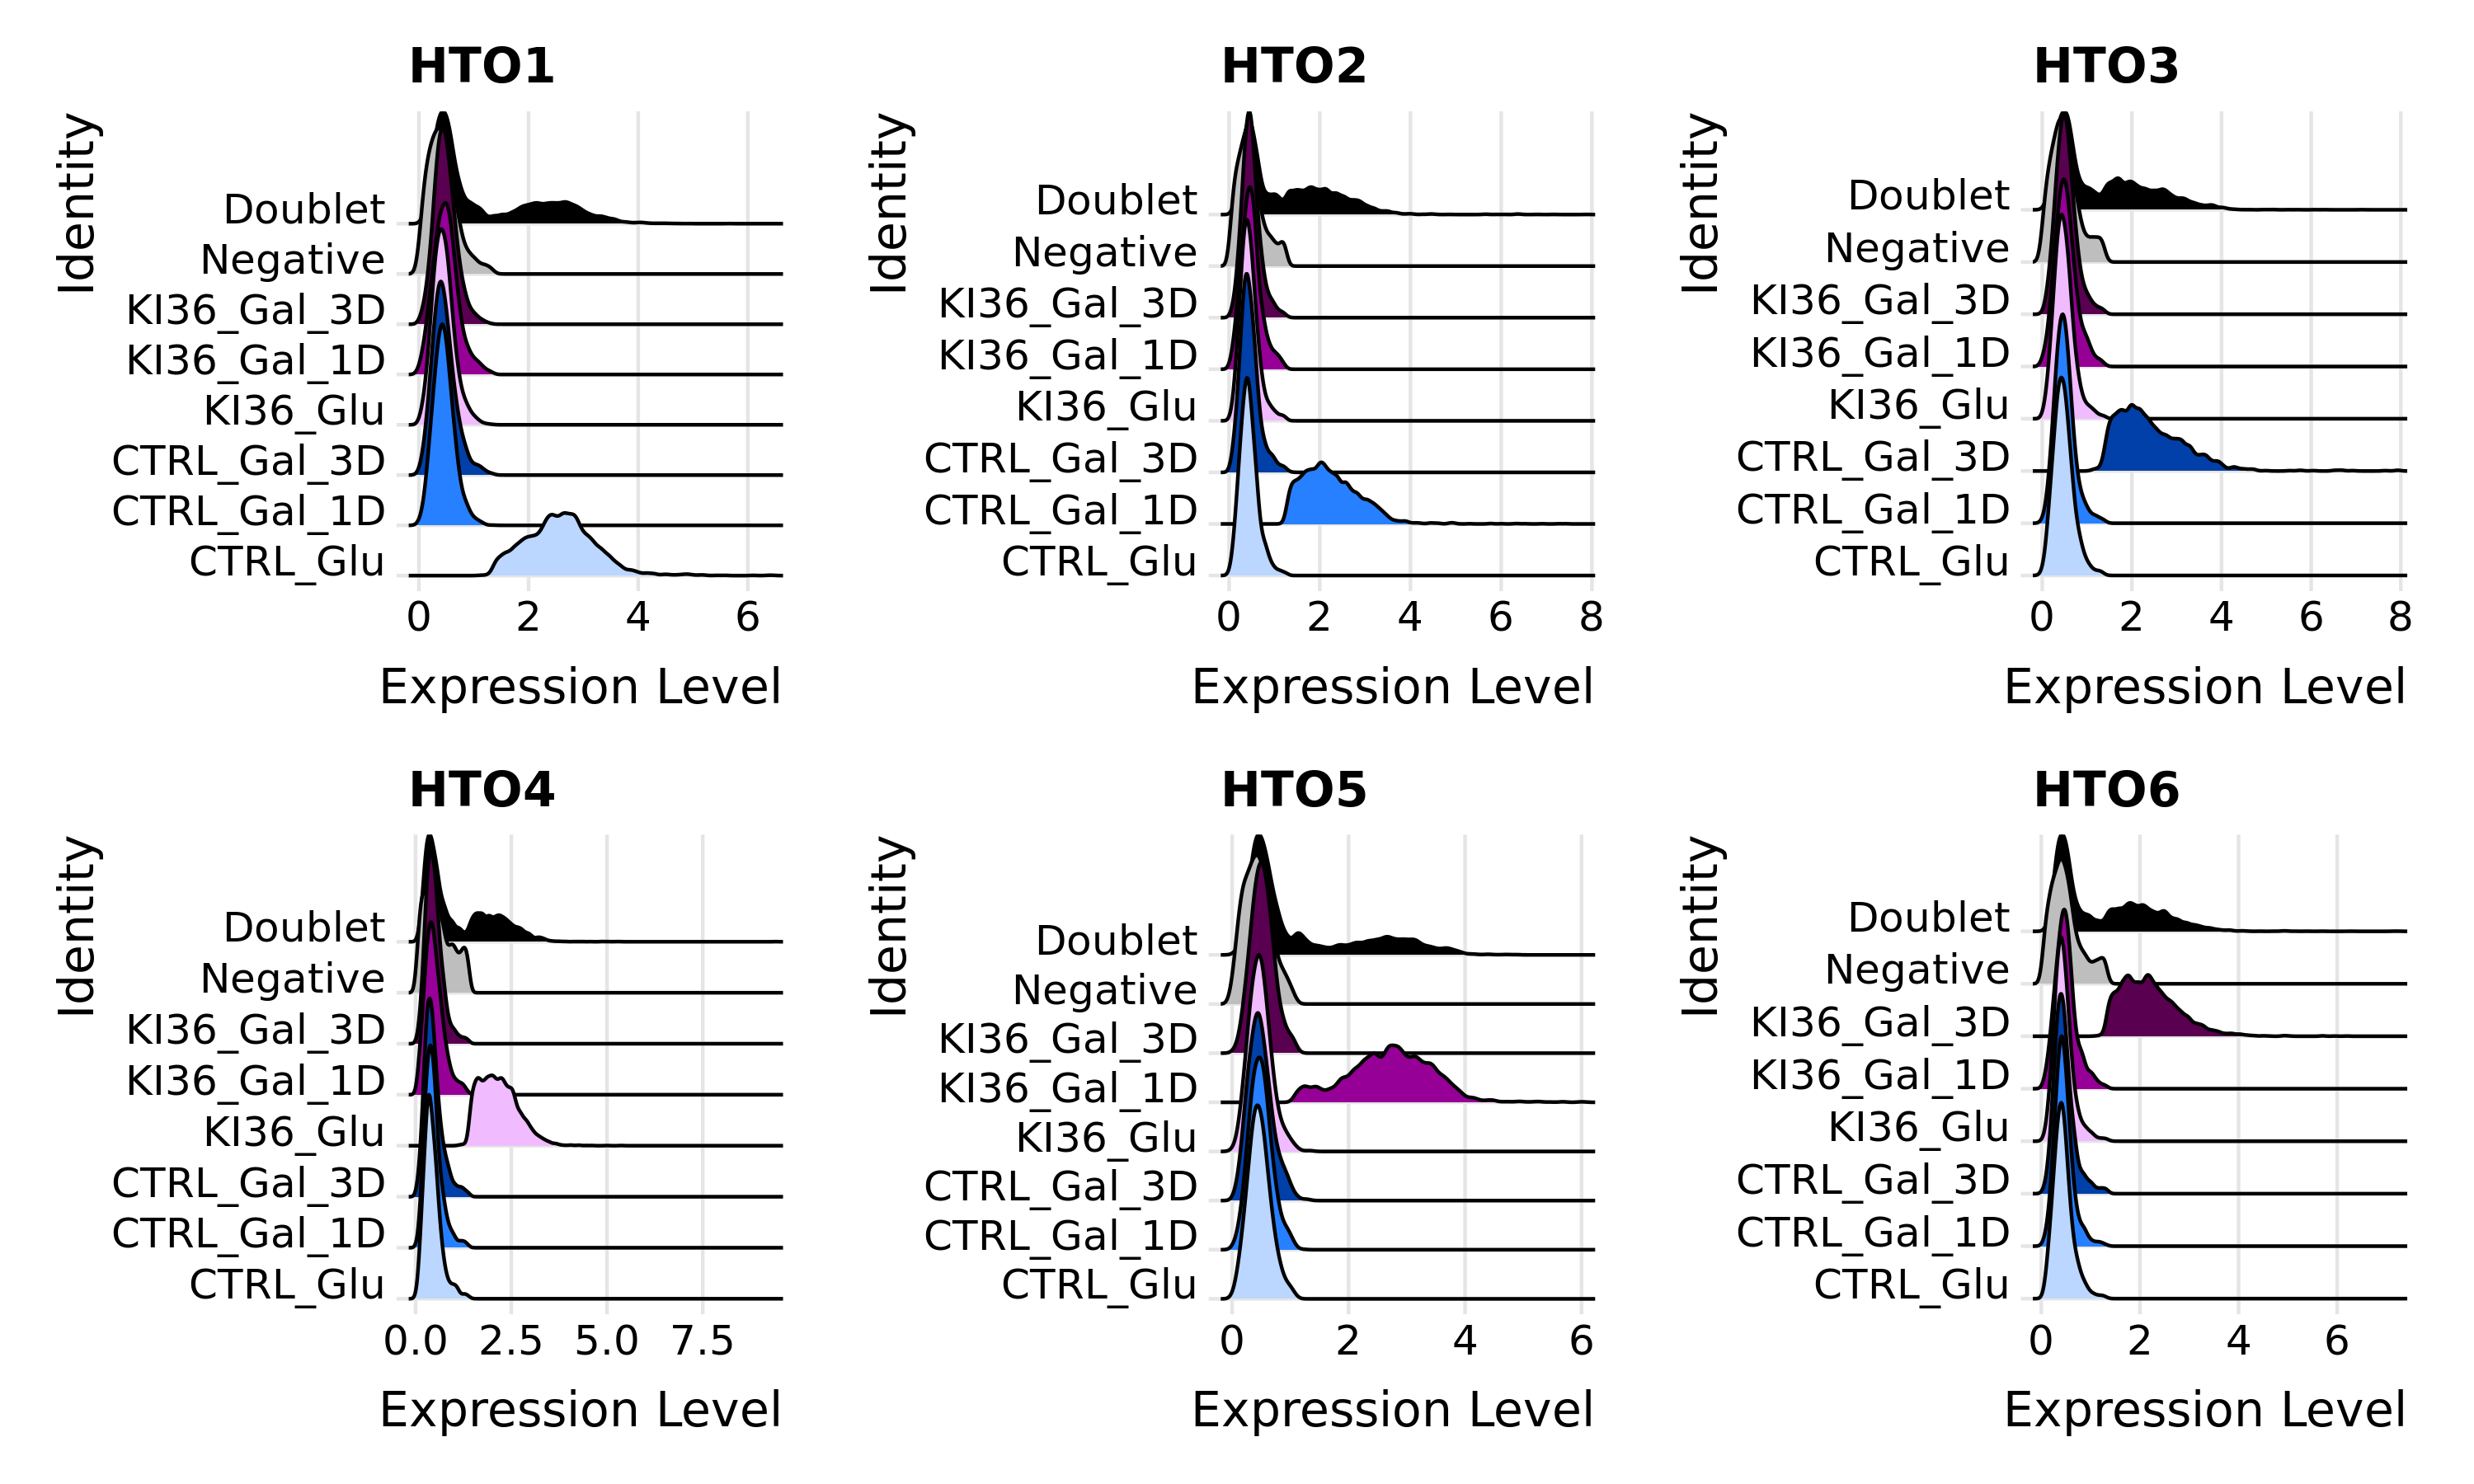

In [9]:
options(repr.plot.width = 10, repr.plot.height = 6, repr.plot.res = 300)
Idents(Gal) <- "hash.ID"
(p1 <- RidgePlot(Gal, assay = "HTO", features = rownames(Gal[["HTO"]])[1:6], ncol = 3, cols = cols))
ggsave(plot = p1, "../plot/Ext_Fig8c_1_1_HTO_demultiplex_RidgePlot.pdf", width = 12, height = 8)

Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Scale for 'fill' is already present. Adding another scale for 'fill', which
will replace the existing scale.



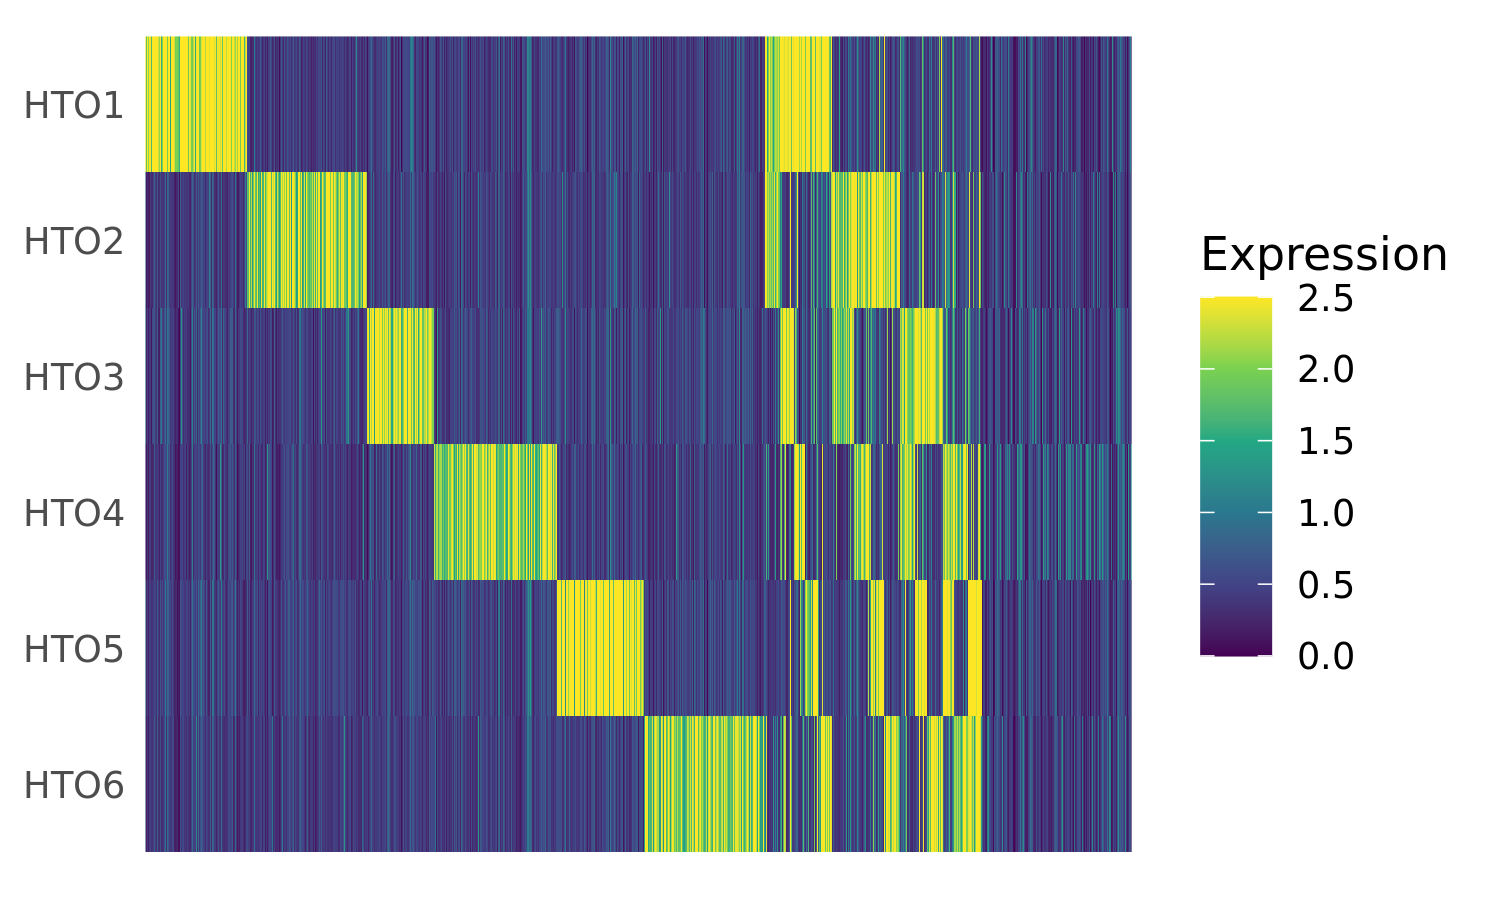

In [10]:
options(repr.plot.width = 5, repr.plot.height = 3, repr.plot.res = 300)
(p2 <- HTOHeatmap(Gal, assay = "HTO") + scale_fill_viridis_c())
ggsave(plot = p2, "../plot/Ext_Fig8b_1_2_HTO_demultiplex_Heatmap.pdf", width = 6, height = 3)

In [11]:
## Quality Control
# nucleus genome ATAC QC
Gal$pct_reads_in_peaks <- Gal$peak_region_fragments / Gal$passed_filters * 100
# Gal <- TSSEnrichment(Gal, fast = T)
Gal <- NucleosomeSignal(Gal)
Gal$log10_nCount_ATAC <- log10(Gal$nCount_ATAC)

In [12]:
mitoSE.rep1 <- readRDS("../data/rep1/mgatk/mgatk.rds")
colnames(mitoSE.rep1) <-  paste0("rep1_", colnames(mitoSE.rep1))
mitoSE.rep2 <- readRDS("../data/rep2/mgatk/mgatk.rds")
colnames(mitoSE.rep2) <-  paste0("rep2_", colnames(mitoSE.rep2))

In [13]:
# combined the two mito summarized experiment object
mitoSE <- cbind(mitoSE.rep1, mitoSE.rep2)[,Cells(Gal)]

In [14]:
Gal$mtDNA_depth = mitoSE$depth
Gal$log10_mtDNA_depth <- log10(Gal$mtDNA_depth)

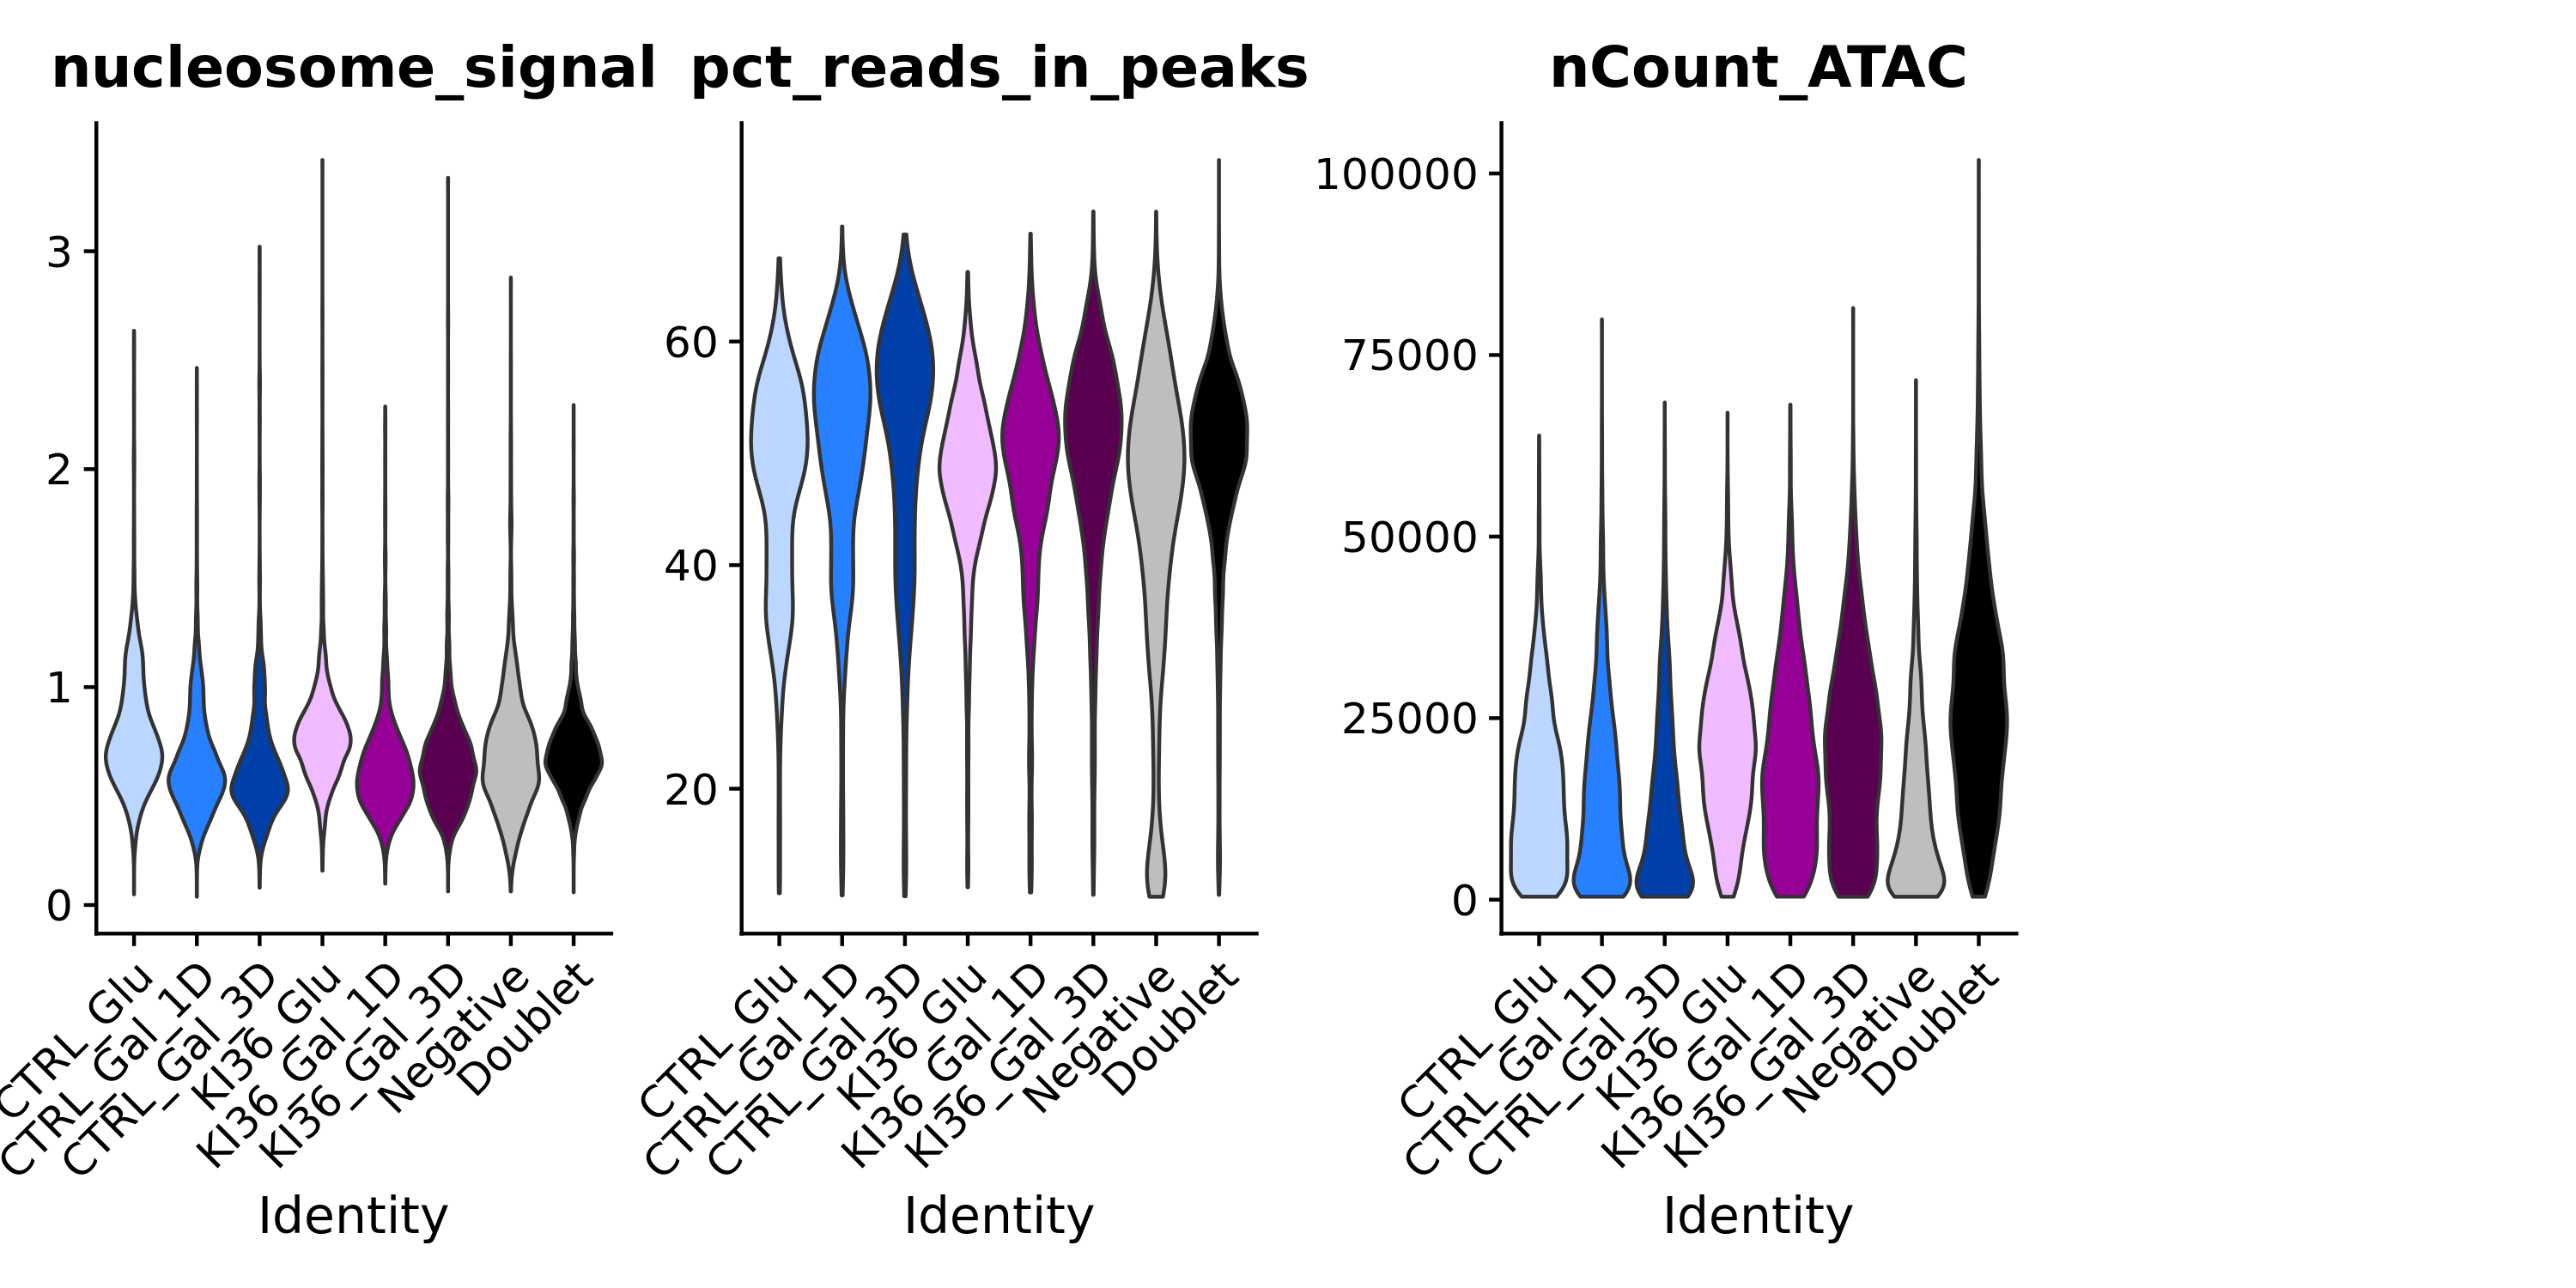

In [15]:
options(repr.plot.width = 10, repr.plot.height = 5, repr.plot.res = 300)
VlnPlot(object = Gal,
        feature = c("nucleosome_signal",
                    "pct_reads_in_peaks",
                    "nCount_ATAC"), pt.size = 0, ncol = 4, cols = cols)

In [16]:
Gal <- subset(
  x = Gal,
  subset = nCount_ATAC > 1000 & 
    nCount_ATAC <= 60000 &
    pct_reads_in_peaks > 20 &
    nucleosome_signal <= 2 &
    mtDNA_depth >= 10)
Gal

An object of class Seurat 
242863 features across 21139 samples within 2 assays 
Active assay: ATAC (242857 features, 0 variable features)
 1 other assay present: HTO

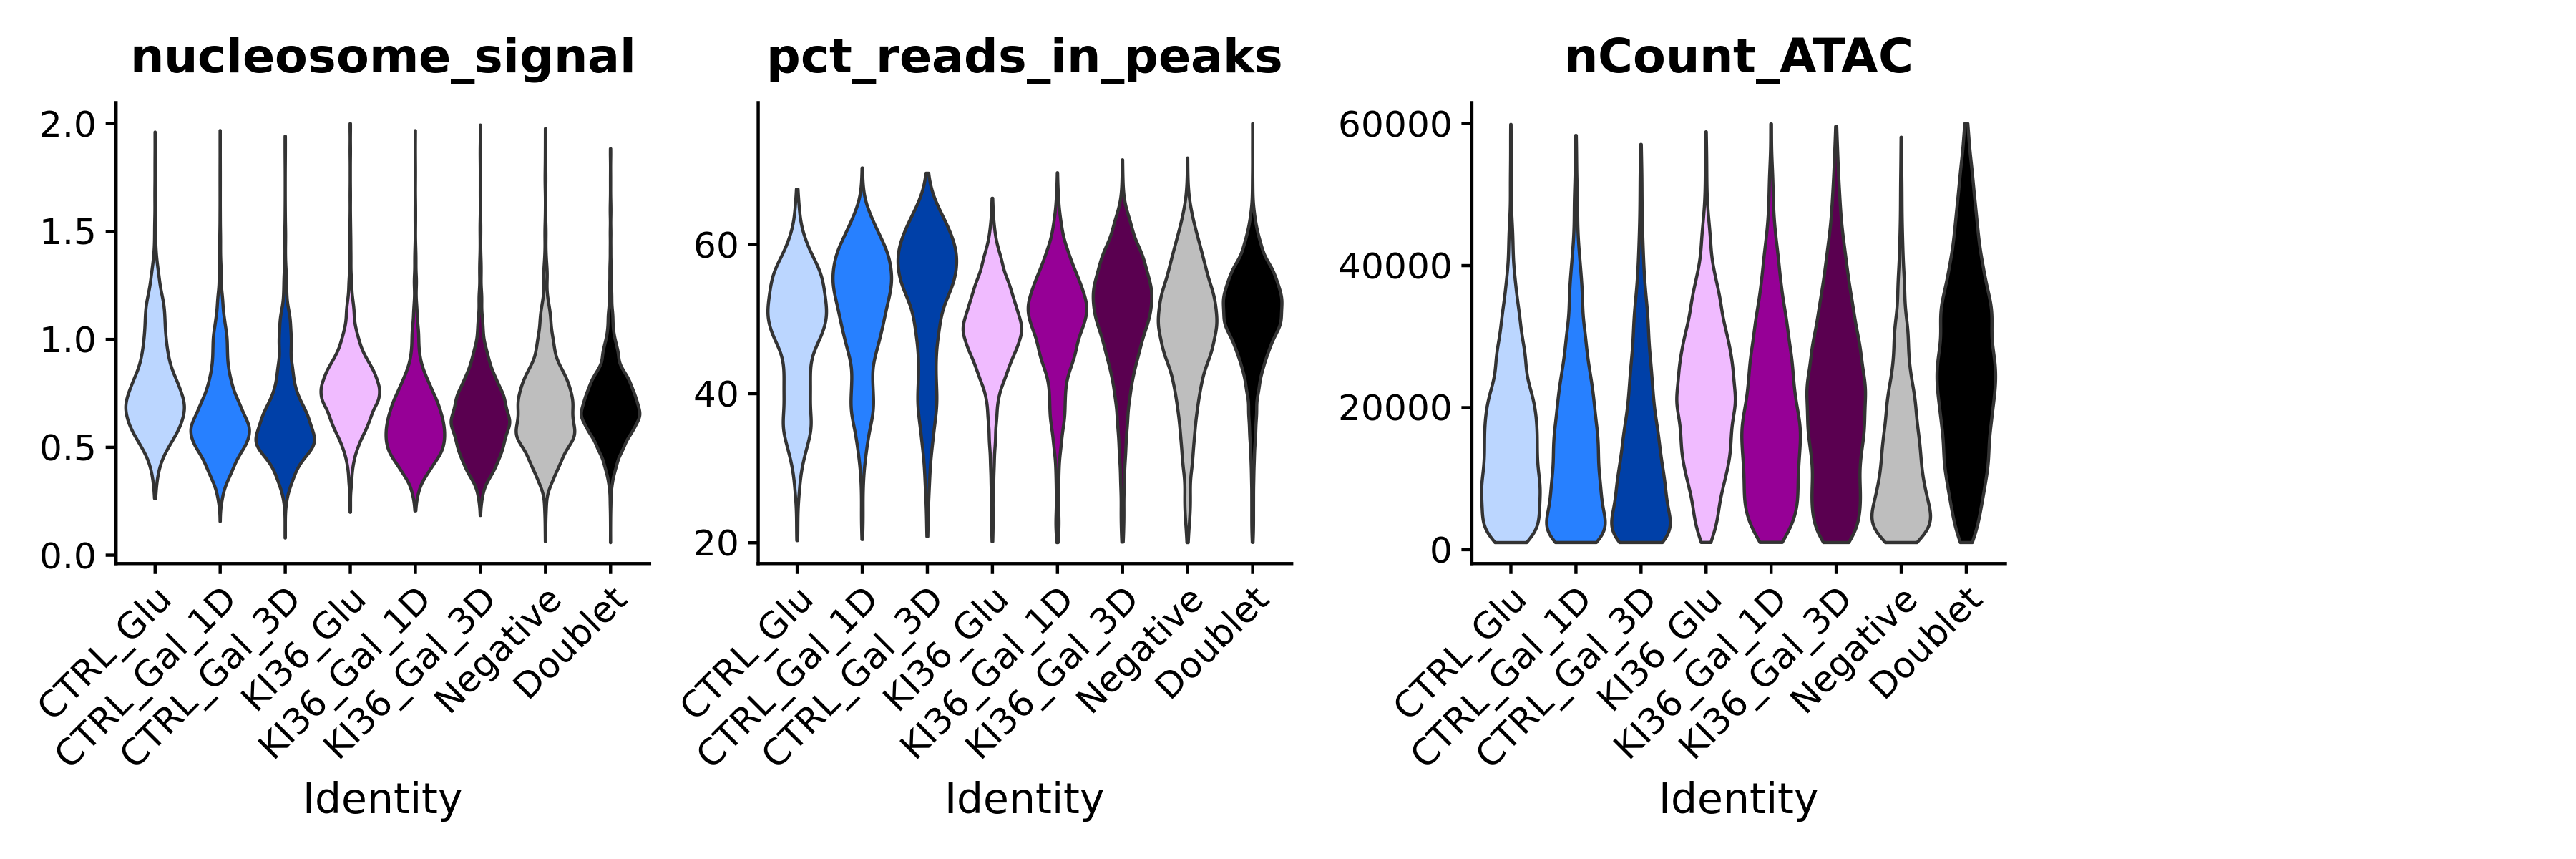

In [17]:
options(repr.plot.width = 12, repr.plot.height = 4, repr.plot.res = 300)
VlnPlot(object = Gal,
        feature = c("nucleosome_signal",
                    "pct_reads_in_peaks",
                    "nCount_ATAC"), pt.size = 0, ncol = 4, cols = cols)

In [18]:
## Latent semantic indexing (LSI): Normalization (TF-IDF) followed by linear dimensional reduction (SVD)
set.seed(123)
DefaultAssay(Gal) <- "ATAC"
Gal <- RunTFIDF(Gal) # term frequency-inverse document frequency
Gal <- FindTopFeatures(Gal, min.cutoff = 'q0')
Gal <- RunSVD(Gal) # singular value decomposition


Performing TF-IDF normalization

Running SVD

Scaling cell embeddings



In [19]:
## Non-linear dimension reduction and clustering
set.seed(123)
Gal <- RunUMAP(object = Gal, reduction = 'lsi', dims = 2:30, reduction.name = "atac.umap", reduction.key = "atacUMAP_", verbose = F)
Gal <- FindNeighbors(object = Gal, reduction = 'lsi', dims = 2:30)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
Computing nearest neighbor graph

Computing SNN



In [20]:
set.seed(123)
Gal <- FindClusters(object = Gal, verbose = FALSE, algorithm = 3, resolution = 0.25)

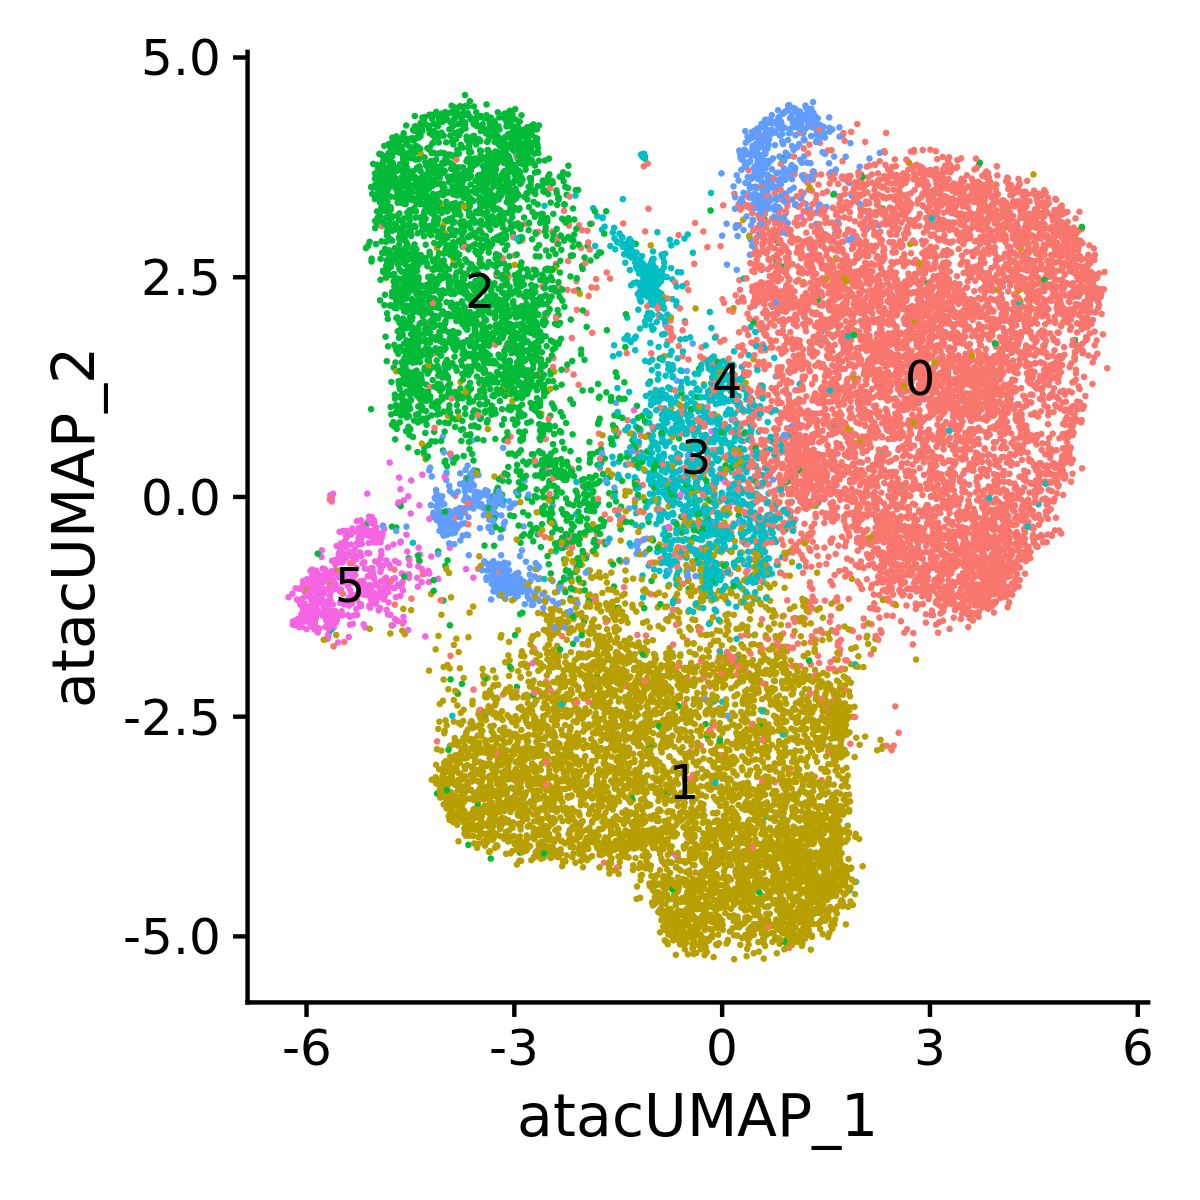

In [21]:
options(repr.plot.width = 4, repr.plot.height = 4, repr.plot.res = 300)
DimPlot(object = Gal, label = TRUE) + NoLegend()

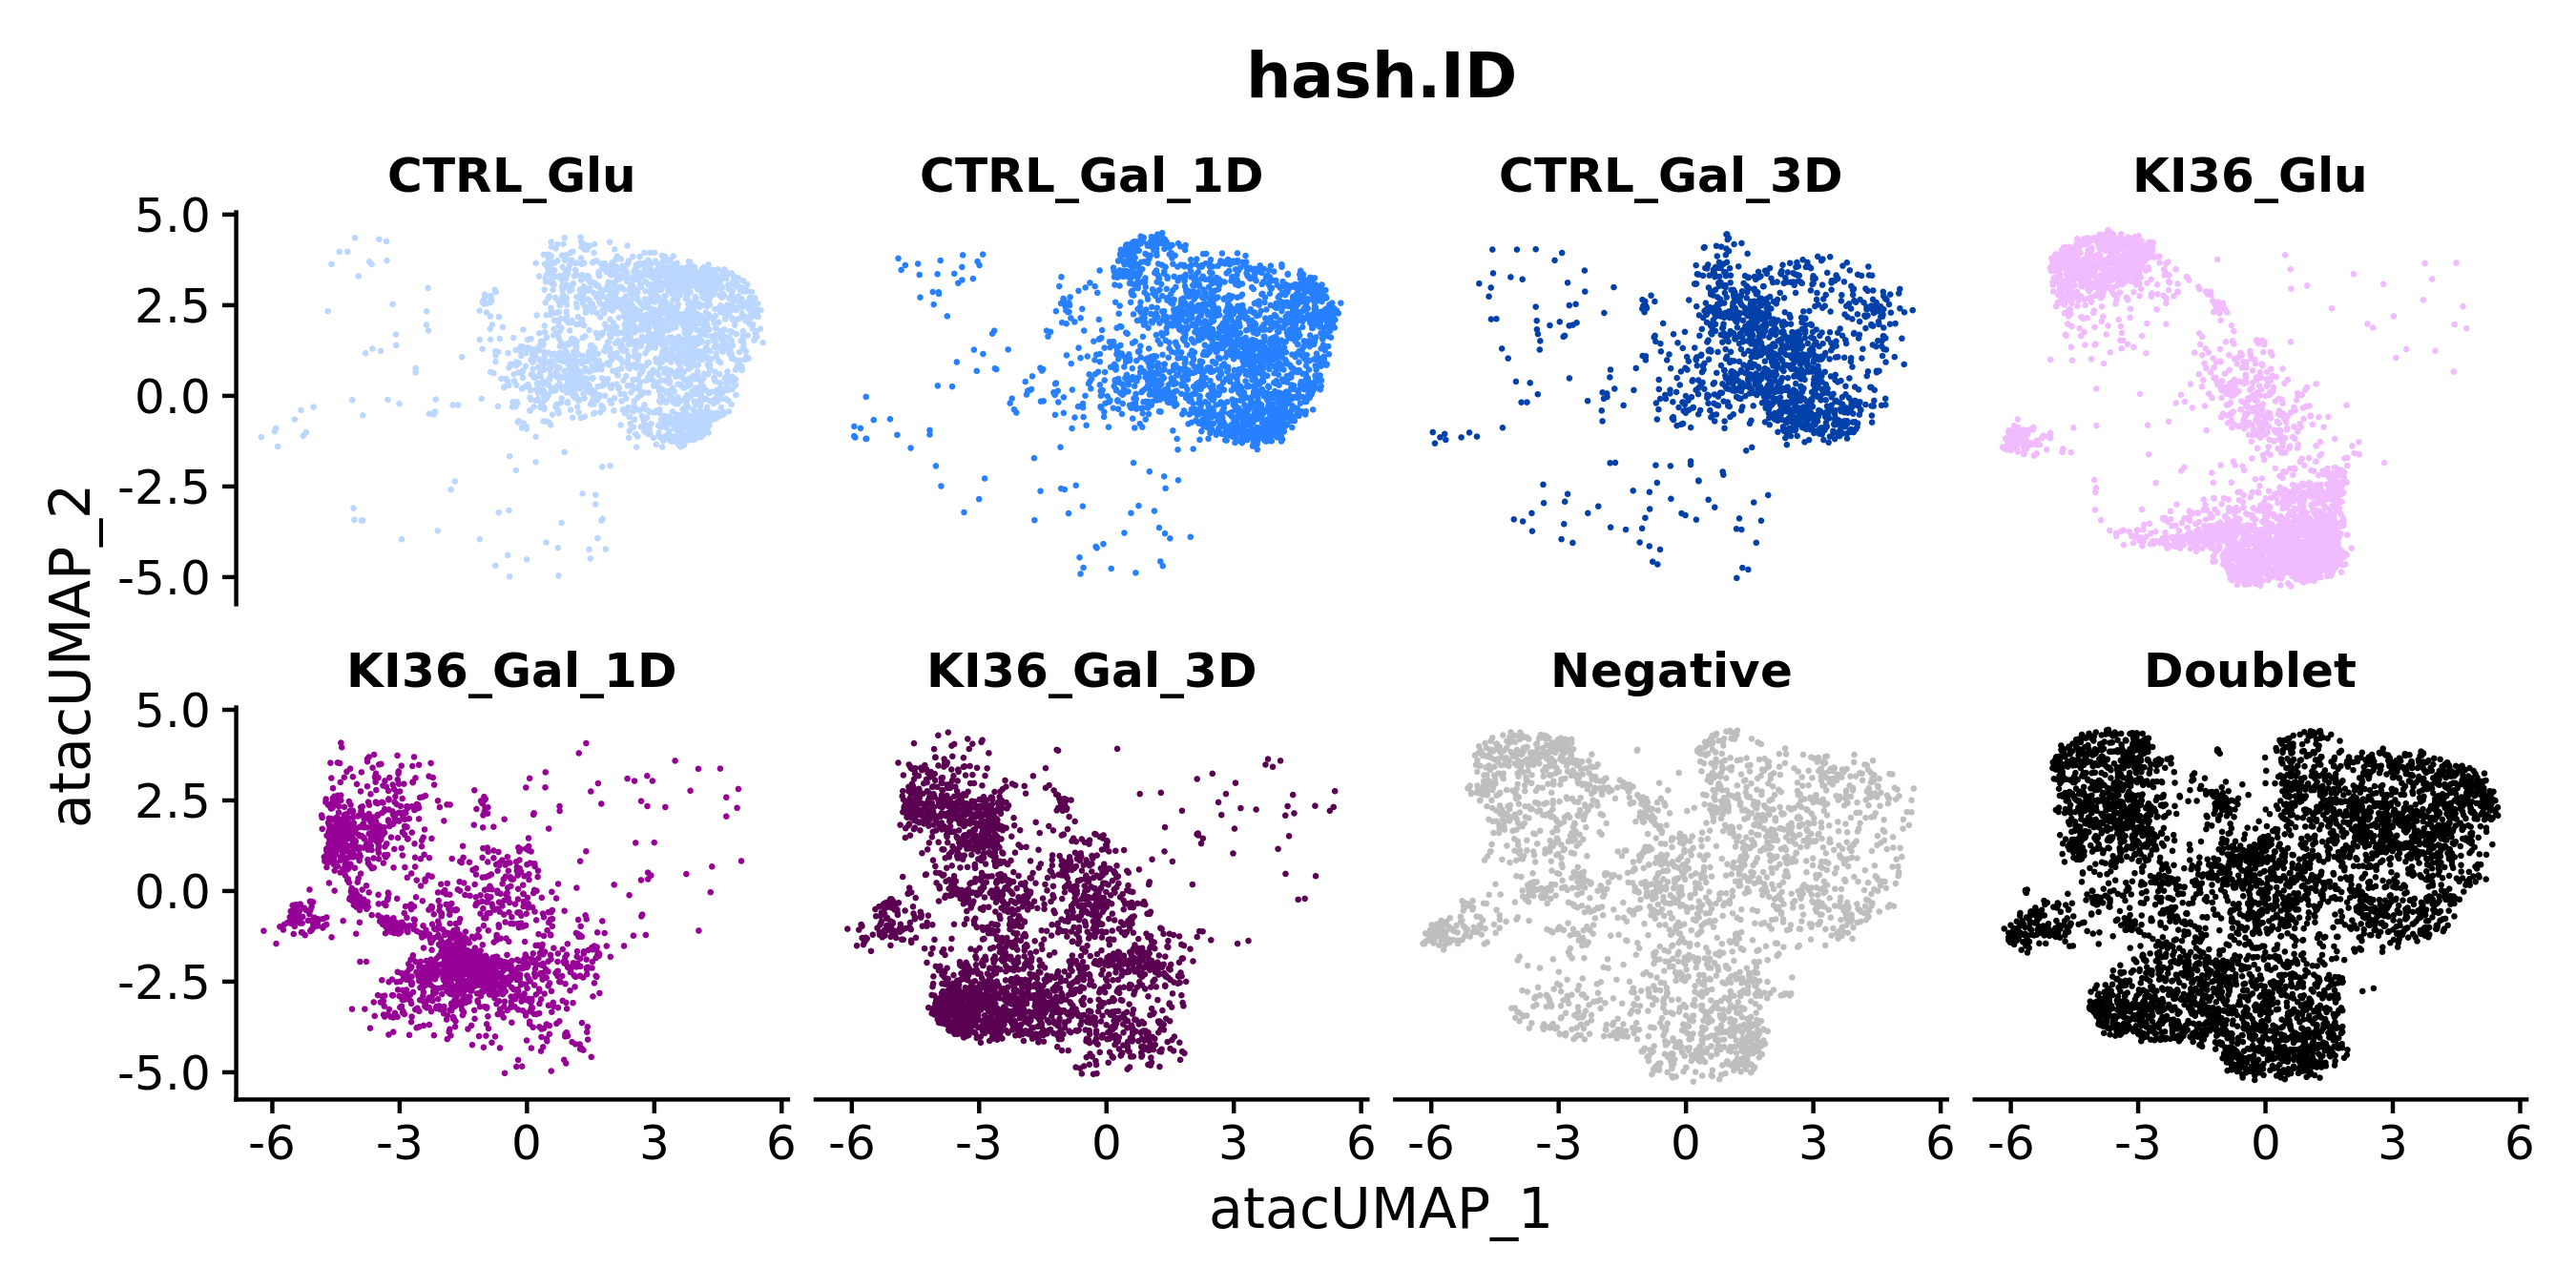

In [22]:
options(repr.plot.width = 9, repr.plot.height = 4.5, repr.plot.res = 300)
DimPlot(object = Gal, group.by = "hash.ID", split.by = "hash.ID", cols = cols, ncol = 4) + NoLegend()

In [23]:
Gal <- subset(Gal, hash.ID != "Doublet" & hash.ID != "Negative")
Gal$cellline <- ifelse(grepl("CTRL", Gal$hash.ID), "CTRL", "KI36")

In [24]:
Idents(Gal) <- "hash.ID"

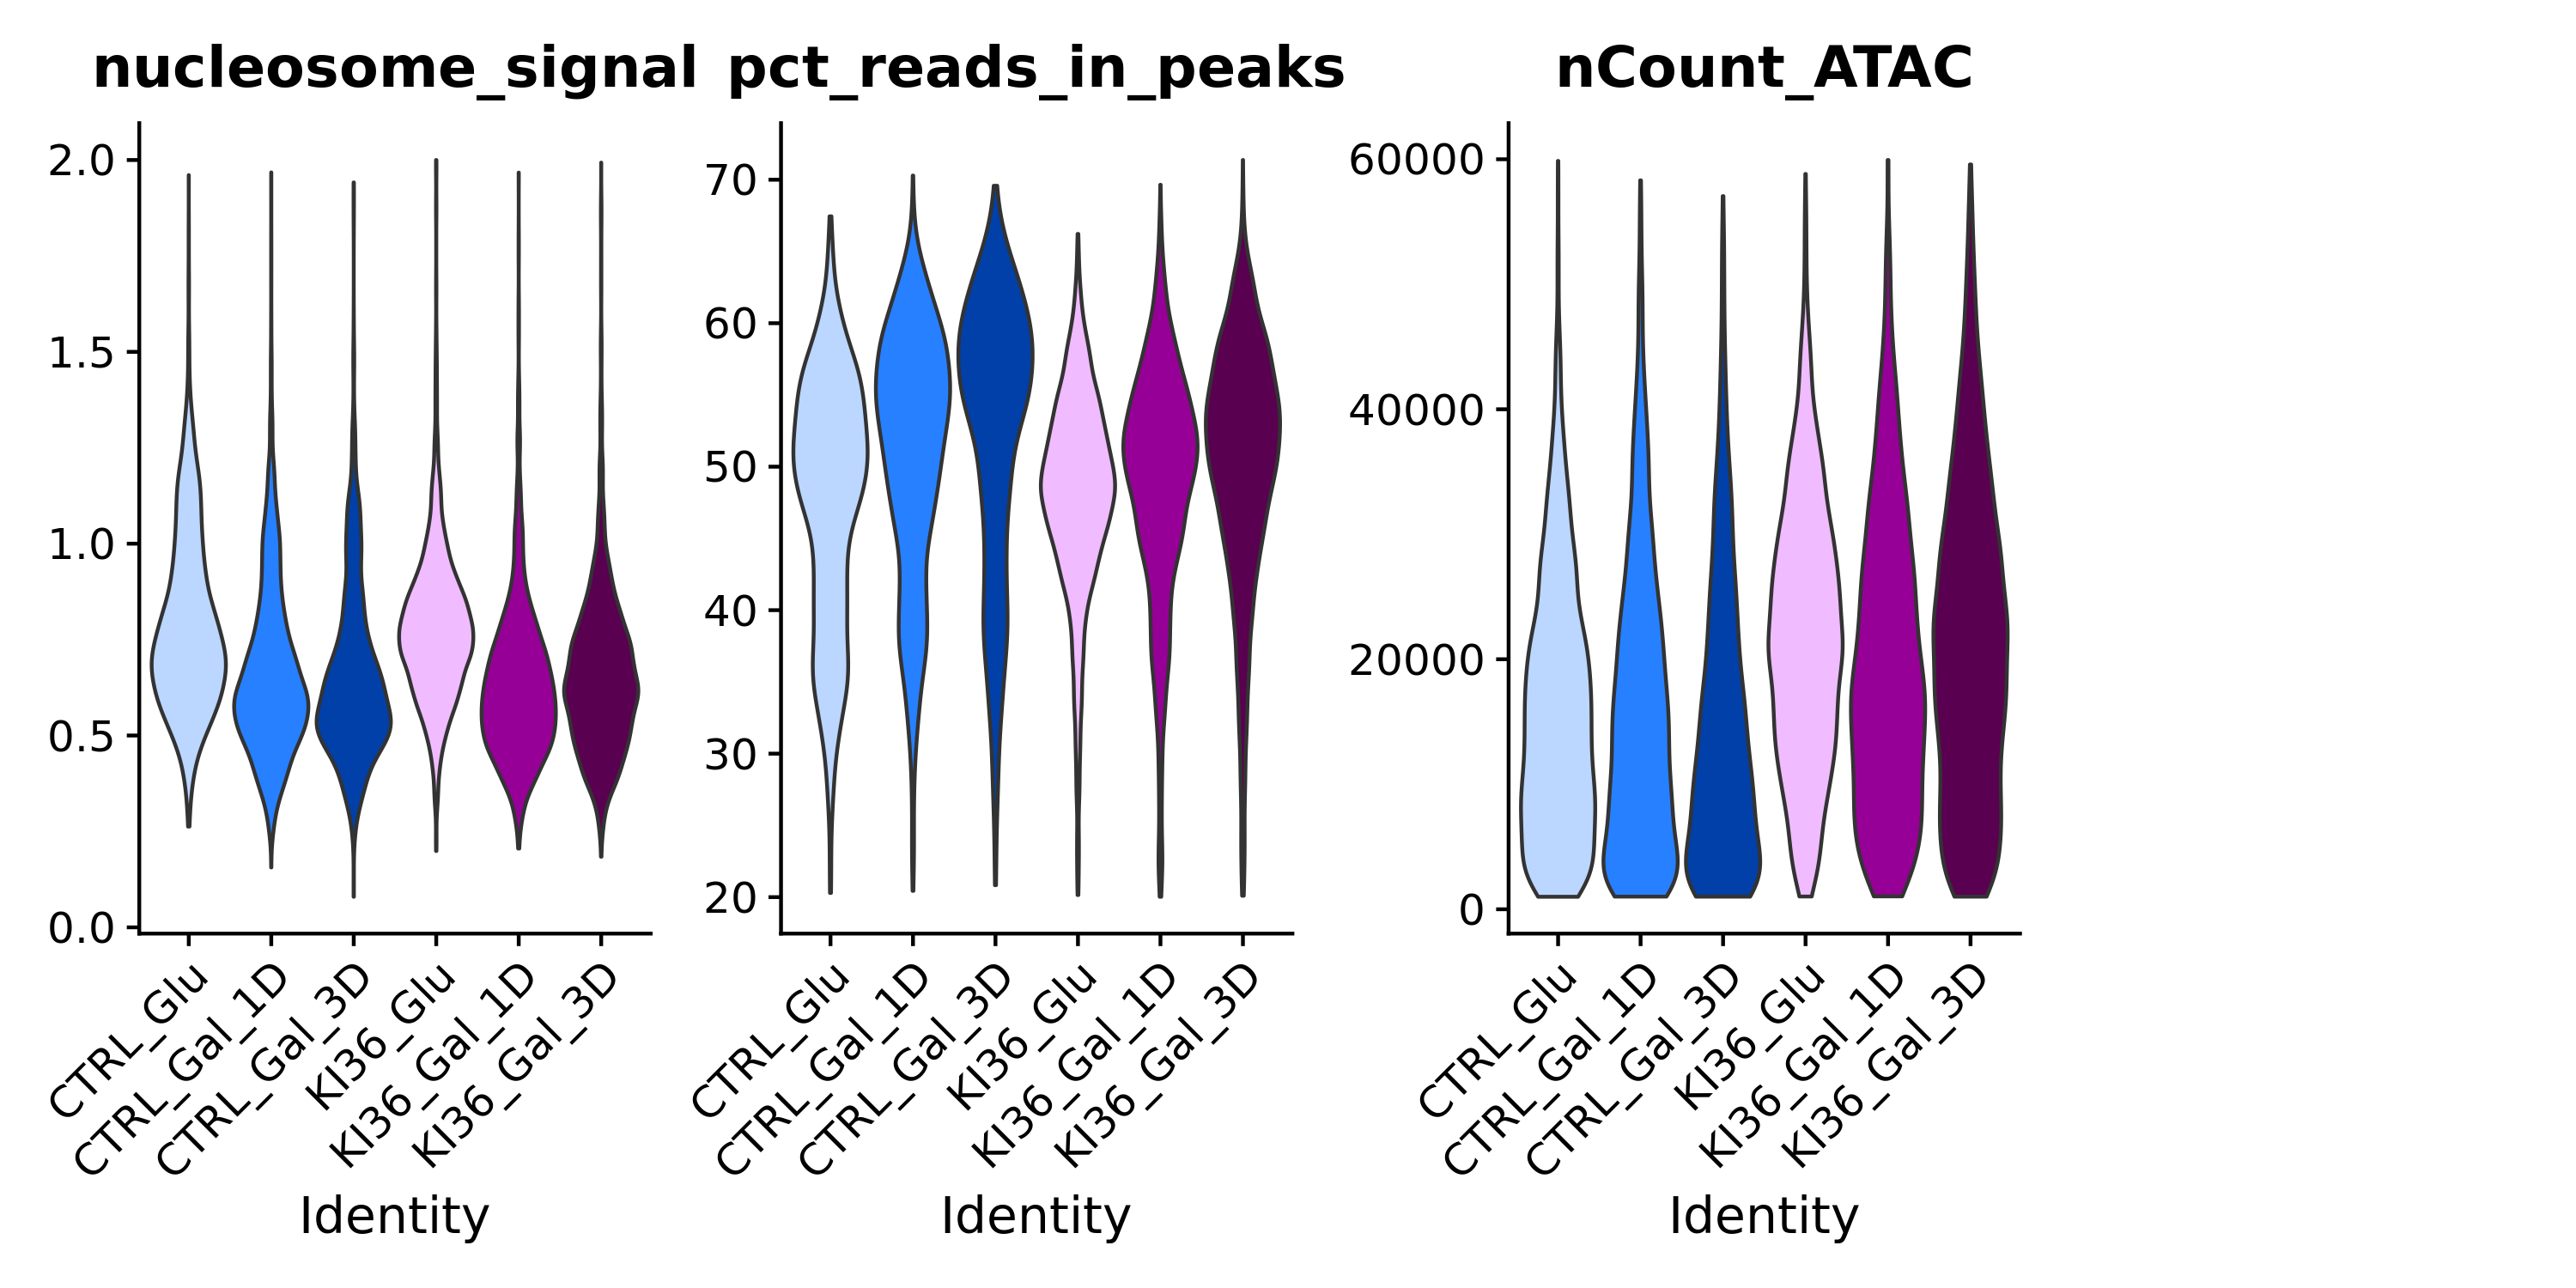

In [25]:
options(repr.plot.width = 10, repr.plot.height = 5, repr.plot.res = 300)
(p3 <- VlnPlot(object = Gal,
        feature = c("nucleosome_signal",
                    "pct_reads_in_peaks",
                    "nCount_ATAC"), pt.size = 0, ncol = 4, cols = cols))

In [26]:
ggsave(plot = p3, "../plot/Ext_Fig8d_1_3_QC.pdf", width = 12, height = 4)

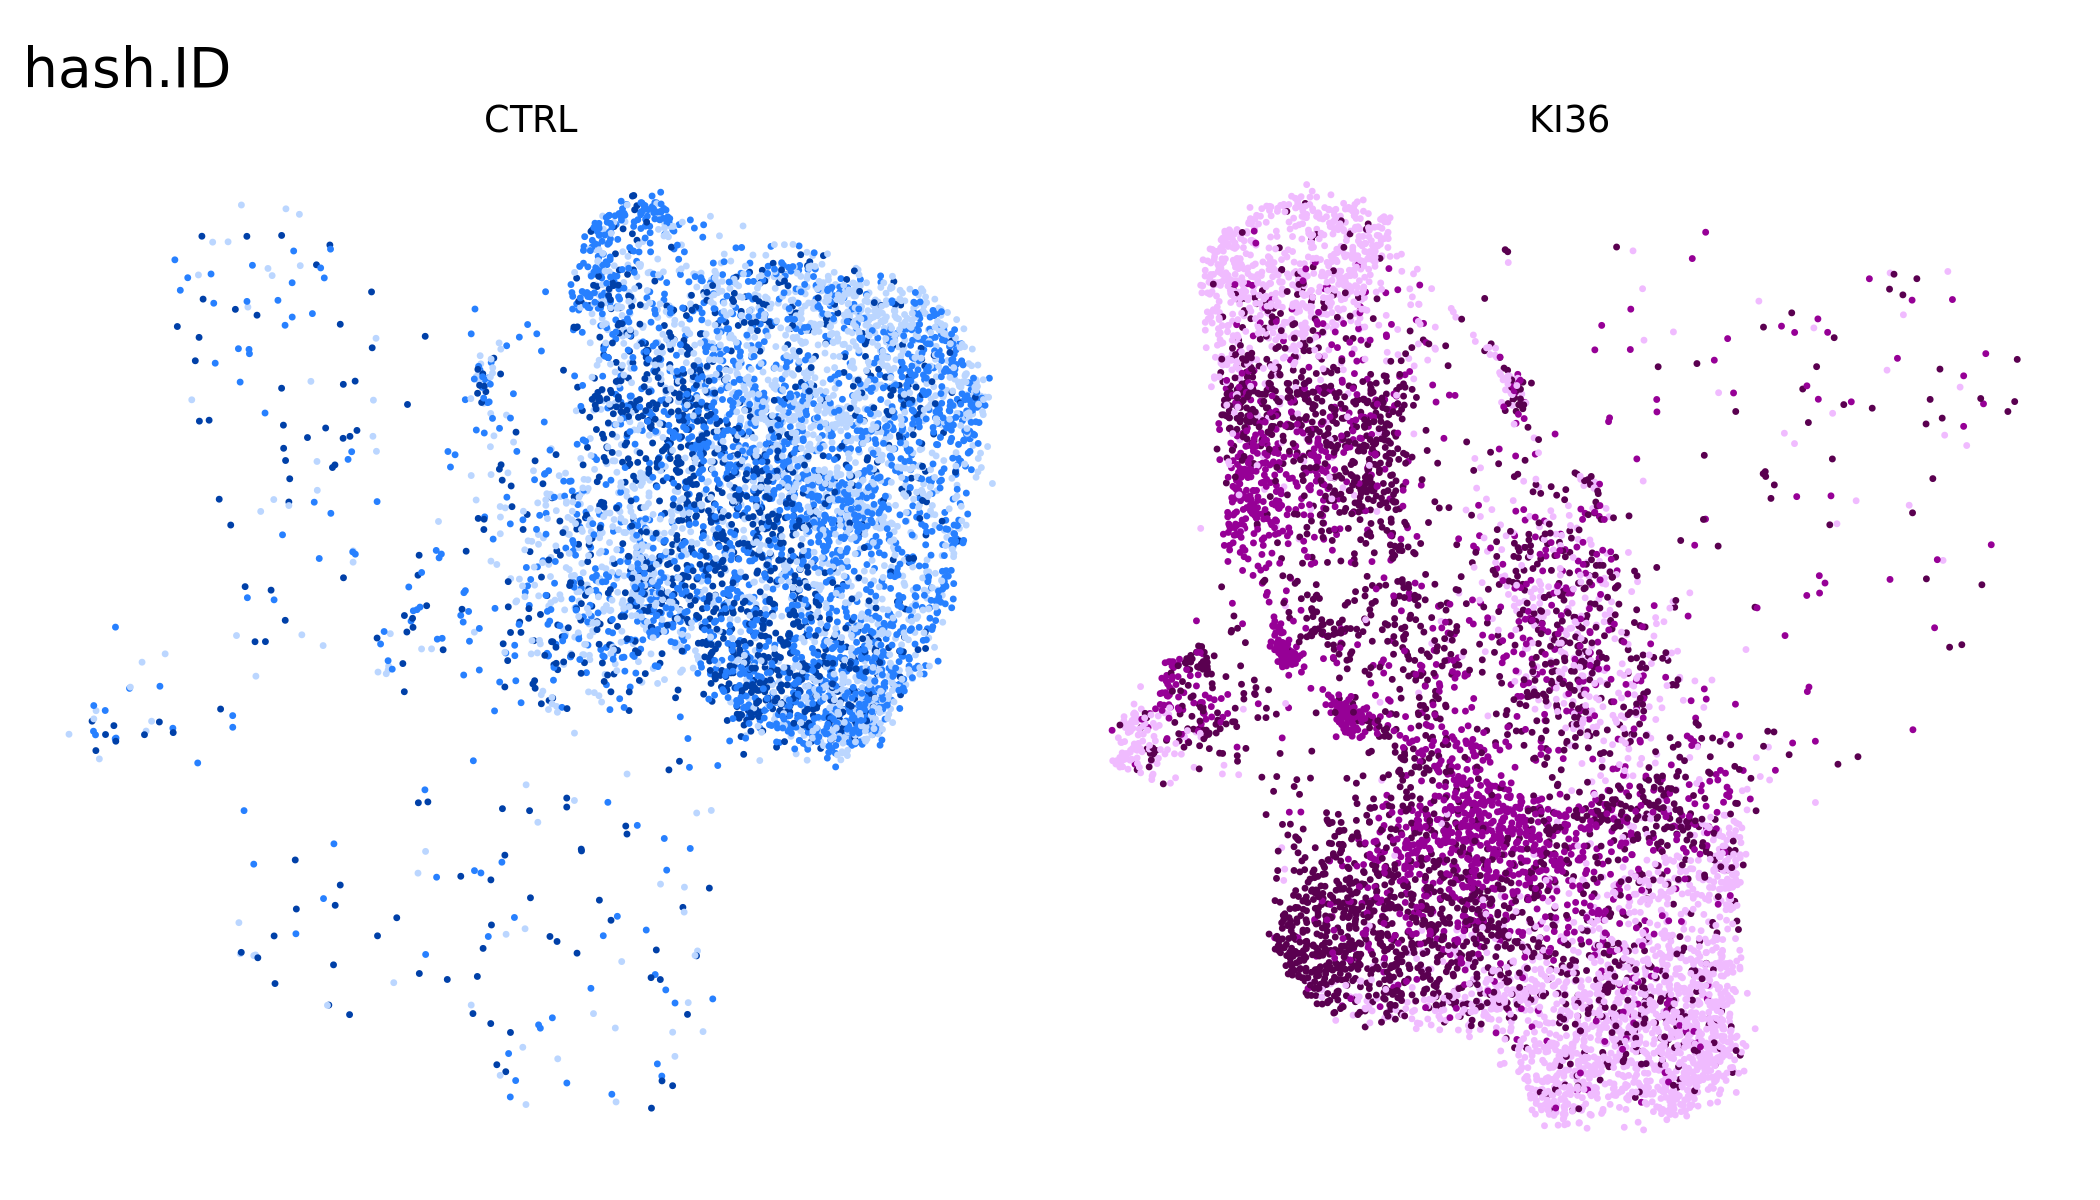

In [27]:
options(repr.plot.width = 7, repr.plot.height = 4, repr.plot.res = 300)
(p4 <- DimPlot(object = Gal, group.by = "hash.ID", split.by = "cellline", cols = cols, ncol = 2) + theme_void() + NoLegend())  


In [28]:
table(Gal$cellline)


CTRL KI36 
6165 7664 

In [29]:
ggsave(plot = p4, "../plot/Fig5b_1_4_UMAP_Treatment_line.pdf", width = 6, height = 3)

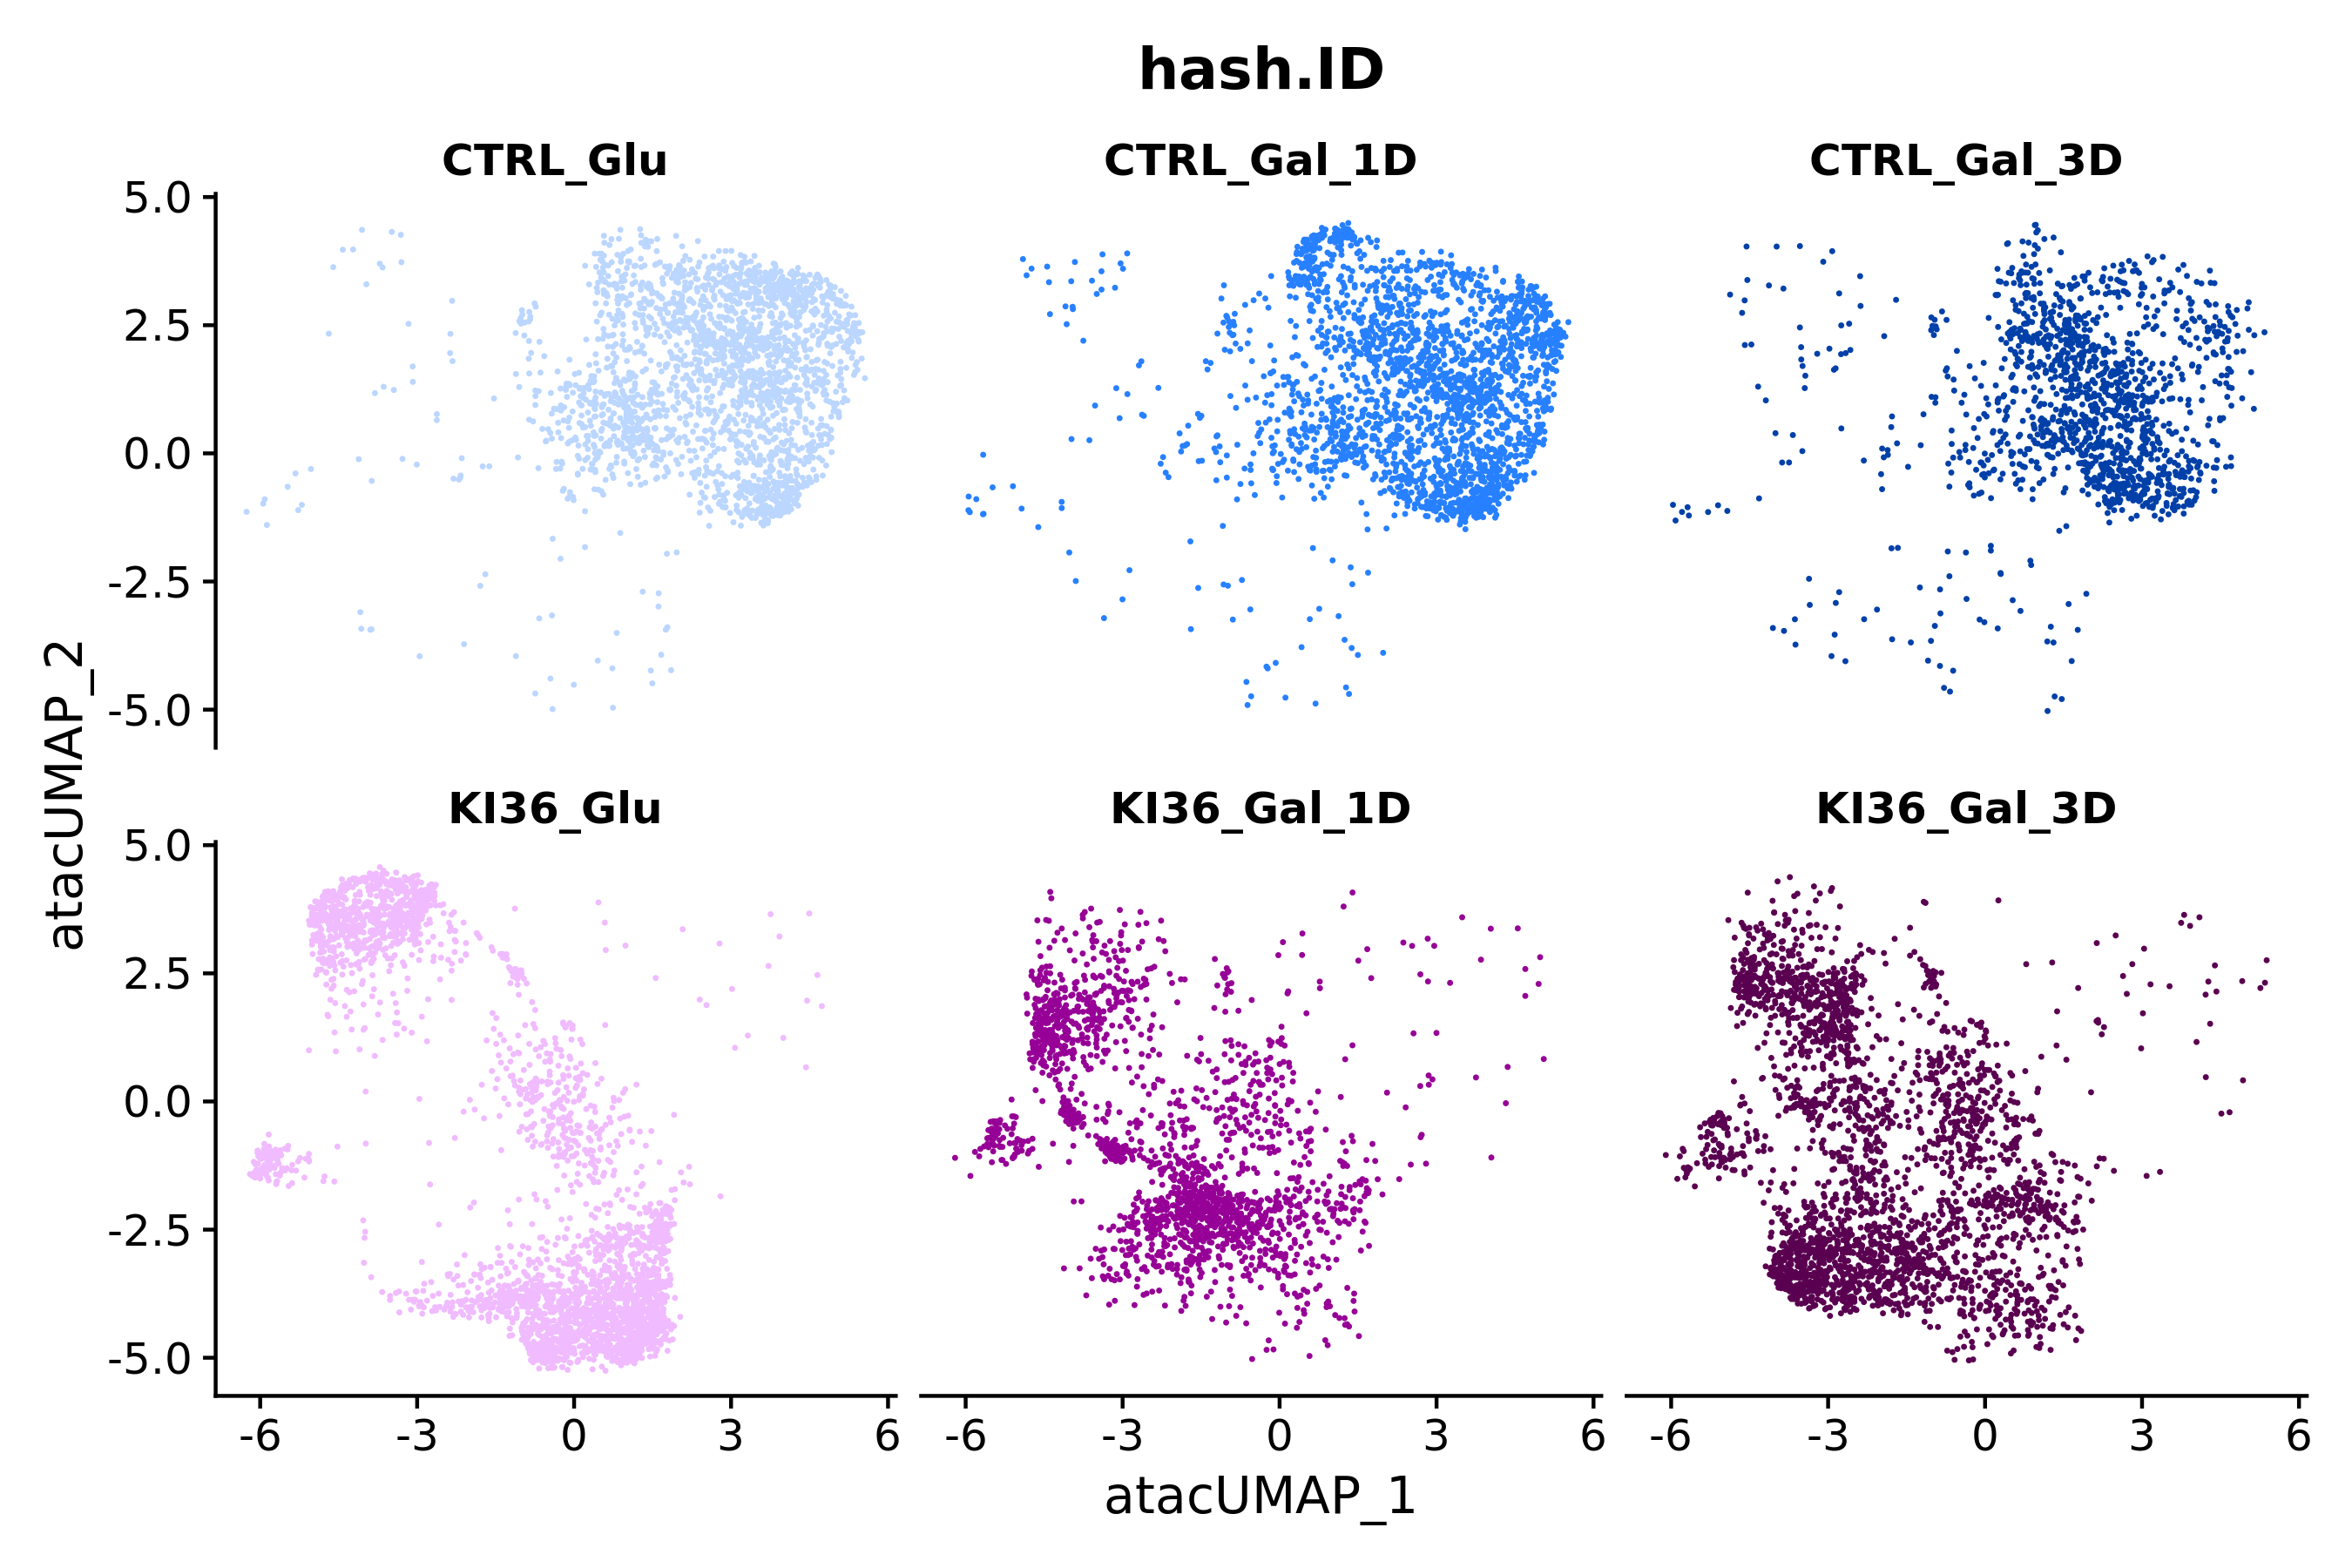

In [30]:
options(repr.plot.width = 9, repr.plot.height = 6, repr.plot.res = 300)
(p5 <- DimPlot(object = Gal, group.by = "hash.ID", split.by = "hash.ID", cols = cols, ncol = 3) + NoLegend())  


In [31]:
table(Gal$hash.ID)


   CTRL_Glu CTRL_Gal_1D CTRL_Gal_3D    KI36_Glu KI36_Gal_1D KI36_Gal_3D 
       2321        2423        1421        2887        1996        2781 
   Negative     Doublet 
          0           0 

In [32]:
ggsave(plot = p5, "../plot/Fig5c_1_5_UMAP_LinexTreatment.pdf", width = 9, height = 6)

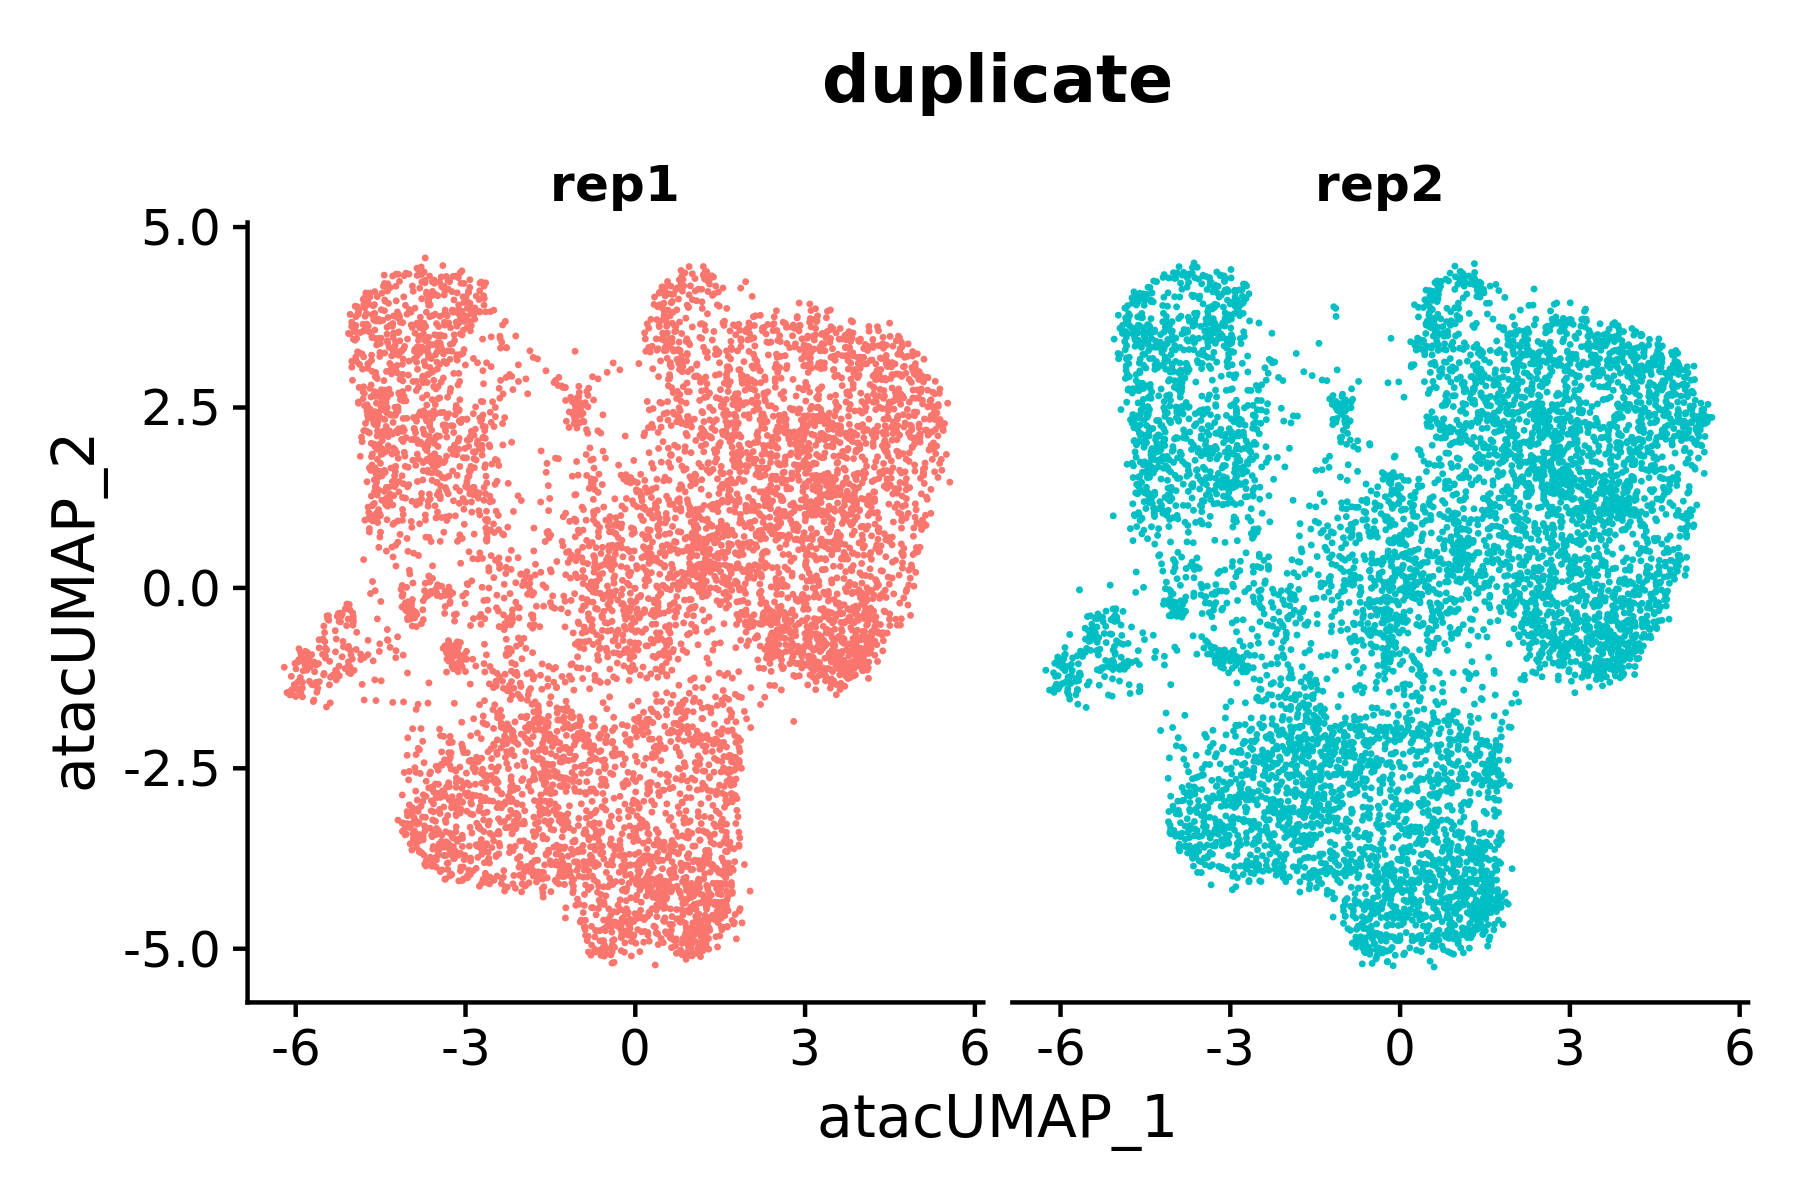

In [33]:
options(repr.plot.width = 6, repr.plot.height = 4, repr.plot.res = 300)
DimPlot(object = Gal, group.by = "duplicate", split.by = "duplicate") + NoLegend()

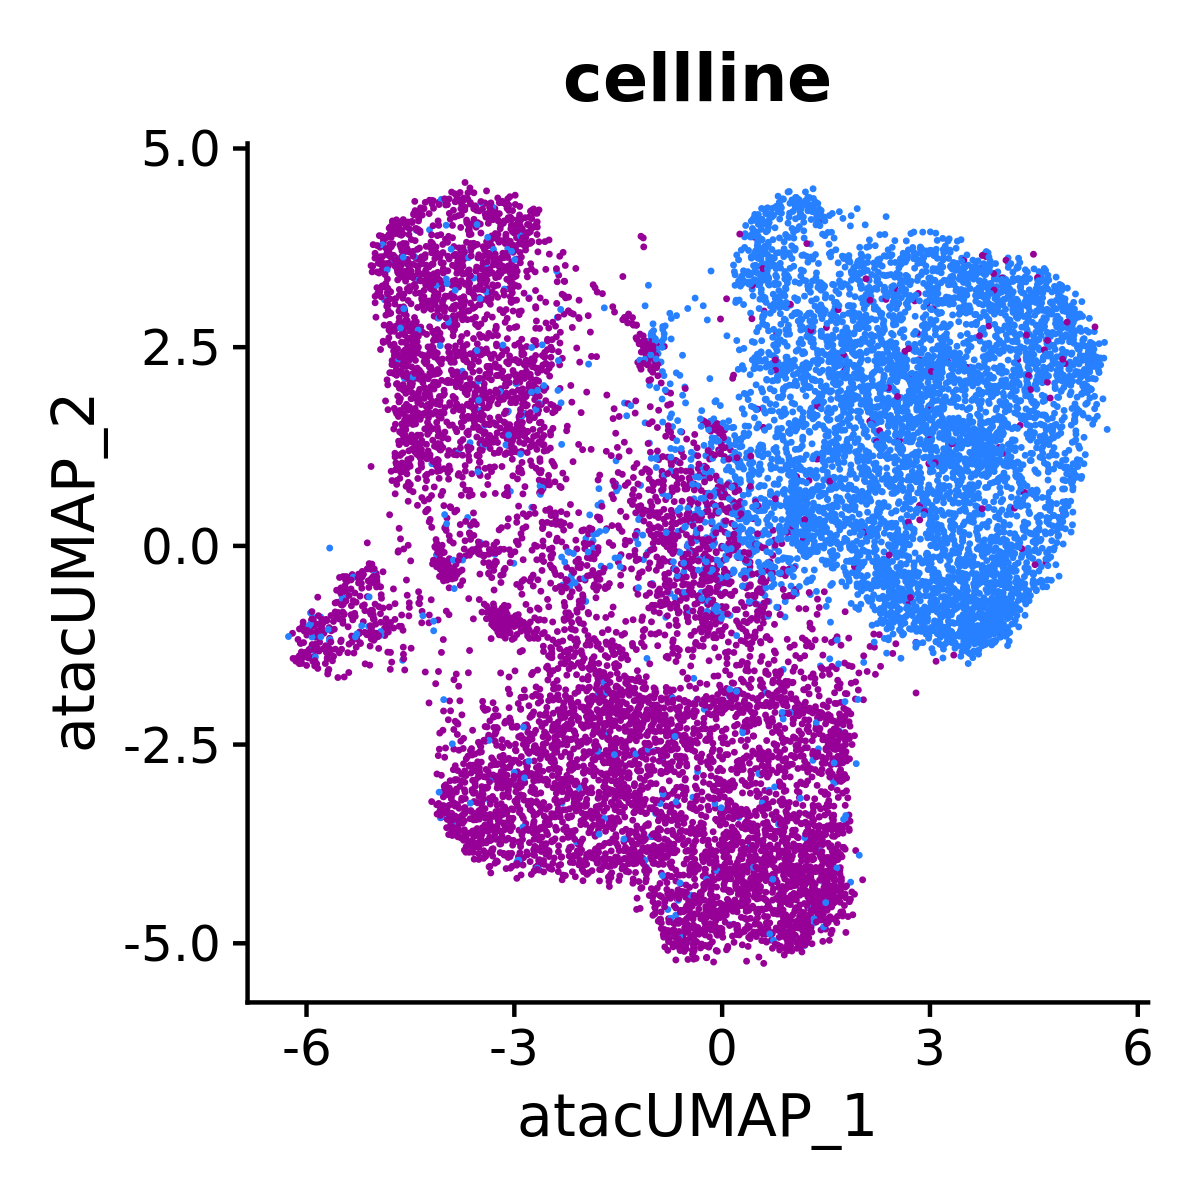

In [34]:
options(repr.plot.width = 4, repr.plot.height = 4, repr.plot.res = 300)
(p6 <- DimPlot(object = Gal, group.by = "cellline", cols = c("CTRL" = "#2780FF", "KI36" = "#960096")) + NoLegend())

In [35]:
ggsave(plot = p6, "../plot/Ext_Fig9a_1_6_UMAP_Line.pdf", width = 4, height = 4)

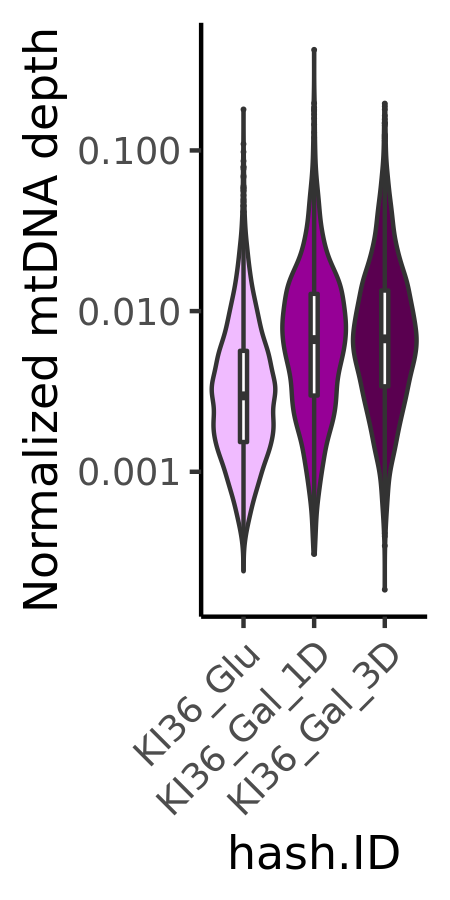

In [36]:
options(repr.plot.width = 1.5, repr.plot.height = 3, repr.plot.res = 300)

(p8 <- ggplot(data = Gal@meta.data %>% filter(grepl("KI36", cellline)), aes(x=hash.ID, y = mtDNA_depth/nCount_ATAC)) +
  geom_violin(scale = "width", aes(fill = hash.ID)) + geom_boxplot(width=0.1, outlier.size=0) + 
  scale_fill_manual(values = cols) + ylab("Normalized mtDNA depth") +
  theme_classic() + NoLegend() + scale_y_log10() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) 
)


In [37]:
ggsave(plot = p8, "../plot/Fig5d_1_8_Vln_mtDNA_depth_KI36.pdf", width = 2, height = 4)

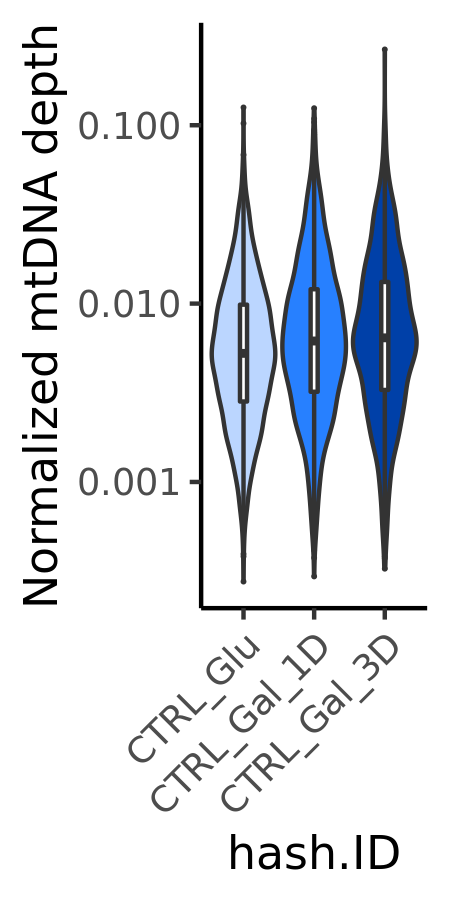

In [38]:
options(repr.plot.width = 1.5, repr.plot.height = 3, repr.plot.res = 300)

(p9 <- ggplot(data = Gal@meta.data %>% filter(grepl("CTRL", cellline)), aes(x=hash.ID, y = mtDNA_depth/nCount_ATAC)) +
  geom_violin(scale = "width", aes(fill = hash.ID)) + geom_boxplot(width=0.1, outlier.size=0) + 
  scale_fill_manual(values = cols) + ylab("Normalized mtDNA depth") +
  theme_classic() + NoLegend() + scale_y_log10() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) 
)
ggsave(plot = p9, "../plot/Ext_Fig9c_1_9_Vln_mtDNA_depth_CTRL.pdf", width = 2, height = 4)

In [42]:
stat.test <- Gal@meta.data %>% select(hash.ID, mtDNA_depth, nCount_ATAC) %>% 
  mutate(hash.ID = as.character(hash.ID), mtDNA_depth_norm = mtDNA_depth/nCount_ATAC) %>%
  wilcox_test(mtDNA_depth_norm ~ hash.ID) %>%
  adjust_pvalue(method = "BH") %>%
  add_significance("p.adj")

In [43]:
stat.test

.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
mtDNA_depth_norm,CTRL_Gal_1D,CTRL_Gal_3D,2423,1421,1667919,1.06e-01,1.325000e-01,ns
mtDNA_depth_norm,CTRL_Gal_1D,CTRL_Glu,2423,2321,3088788,4.31e-09,7.183333e-09,****
mtDNA_depth_norm,CTRL_Gal_1D,KI36_Gal_1D,2423,1996,2400122,6.69e-01,6.690000e-01,ns
mtDNA_depth_norm,CTRL_Gal_1D,KI36_Gal_3D,2423,2781,3219831,6.00e-03,9.000000e-03,**
mtDNA_depth_norm,CTRL_Gal_1D,KI36_Glu,2423,2887,4906483,1.89e-141,1.417500e-140,****
mtDNA_depth_norm,CTRL_Gal_3D,CTRL_Glu,1421,2321,1862574,2.80e-11,6.000000e-11,****
mtDNA_depth_norm,CTRL_Gal_3D,KI36_Gal_1D,1421,1996,1450247,2.59e-01,2.988462e-01,ns
mtDNA_depth_norm,CTRL_Gal_3D,KI36_Gal_3D,1421,2781,1949507,4.78e-01,5.121429e-01,ns
mtDNA_depth_norm,CTRL_Gal_3D,KI36_Glu,1421,2887,2921268,9.11e-114,3.416250e-113,****


In [45]:
Gal$mtDNA_depth_norm = Gal$mtDNA_depth/Gal$nCount_ATAC

In [46]:
feature.stat <- summarizer(Gal@meta.data, numeric_cols = c("nCount_ATAC", "mtDNA_depth","mtDNA_depth_norm"), hash.ID) %>% 
  tidyr::pivot_longer(cols = -hash.ID, names_to = "name", values_to = "value") %>% 
  mutate(
    feature = sub("^(.*)_[^_]+$", "\\1", name),
    stat = sub("^.*_([^_]+)$", "\\1", name) 
  ) %>% 
  select(hash.ID, feature, stat, value) %>% 
  tidyr::pivot_wider(names_from = hash.ID, values_from = value)
feature.stat

feature,stat,CTRL_Glu,CTRL_Gal_1D,CTRL_Gal_3D,KI36_Glu,KI36_Gal_1D,KI36_Gal_3D
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
nCount_ATAC,min,1.001000e+03,1.012000e+03,1.010000e+03,1.022000e+03,1.032000e+03,1.009000e+03
nCount_ATAC,q05,2.173000e+03,1.633400e+03,1.391000e+03,4.922900e+03,3.258000e+03,2.824000e+03
nCount_ATAC,median,1.476400e+04,1.400500e+04,1.166300e+04,2.138600e+04,1.785650e+04,2.055500e+04
nCount_ATAC,q95,3.538200e+04,3.853640e+04,3.657300e+04,3.988380e+04,4.093300e+04,4.341900e+04
nCount_ATAC,max,5.986700e+04,5.831000e+04,5.705000e+04,5.882300e+04,5.994000e+04,5.958200e+04
mtDNA_depth,min,1.023000e+01,1.001000e+01,1.009000e+01,1.001000e+01,1.009000e+01,1.034000e+01
mtDNA_depth,q05,1.713000e+01,1.766200e+01,1.618000e+01,1.492400e+01,2.020000e+01,2.438000e+01
mtDNA_depth,median,6.586000e+01,7.429000e+01,6.617000e+01,5.637000e+01,1.079950e+02,1.273700e+02
mtDNA_depth,q95,1.985500e+02,2.074410e+02,2.290900e+02,2.095860e+02,3.431900e+02,3.505100e+02


In [47]:
pull_coverage <- function(SE, cells, resolution = 5){
  zoo::rollmean(rowMeans(assays(SE)[['coverage']]), resolution)
}

CTRL_Glu_3D_CB <- WhichCells(Gal, idents = "CTRL_Glu"    )
CTRL_Gal_1D_CB <- WhichCells(Gal, idents = "CTRL_Gal_1D" )
CTRL_Gal_3D_CB <- WhichCells(Gal, idents = "CTRL_Gal_3D" )
KI36_Glu_3D_CB <- WhichCells(Gal, idents = "KI36_Glu"    )
KI36_Gal_1D_CB <- WhichCells(Gal, idents = "KI36_Gal_1D" )
KI36_Gal_3D_CB <- WhichCells(Gal, idents = "KI36_Gal_3D" )

cov_df <- data.frame(
  pos = zoo::rollmean(1:16569, 5),
  CTRL_Glu    = pull_coverage(mitoSE[,CTRL_Glu_3D_CB]),
  CTRL_Gal_1D = pull_coverage(mitoSE[,CTRL_Gal_1D_CB]),
  CTRL_Gal_3D = pull_coverage(mitoSE[,CTRL_Gal_3D_CB]),
  KI36_Glu    = pull_coverage(mitoSE[,KI36_Glu_3D_CB]),
  KI36_Gal_1D = pull_coverage(mitoSE[,KI36_Gal_1D_CB]),
  KI36_Gal_3D = pull_coverage(mitoSE[,KI36_Gal_3D_CB]))

In [48]:
source("../../global/mtGene_color.R")

p9 <- cov_df %>% reshape2::melt(id.vars = "pos") %>% # dplyr::filter(value > 5) %>%
  ggplot() +
  geom_line(aes(x = pos, y = value, color = variable)) +
  #scale_y_continuous(limits = c(-3, 75), expand = c(0,0)) +
  scale_x_continuous(breaks = seq(0,16596, by = 3000), expand = c(0,0)) + 
  scale_color_manual(values = cols) +
  labs(x = "Position on mtDNA chromosome", y = "Roll mean coverage") + 
  geom_rect(data = mitochondrial_data, aes(xmin = Starting, xmax = Ending, ymin = -10, ymax = 0, fill = color), alpha = 1) +
  scale_fill_manual(values = mtGene_colors) +
  # coord_polar() + 
  guides(fill=guide_legend(ncol=2))+
  theme_classic() + NoLegend() + facet_wrap(~variable, ncol = 3)

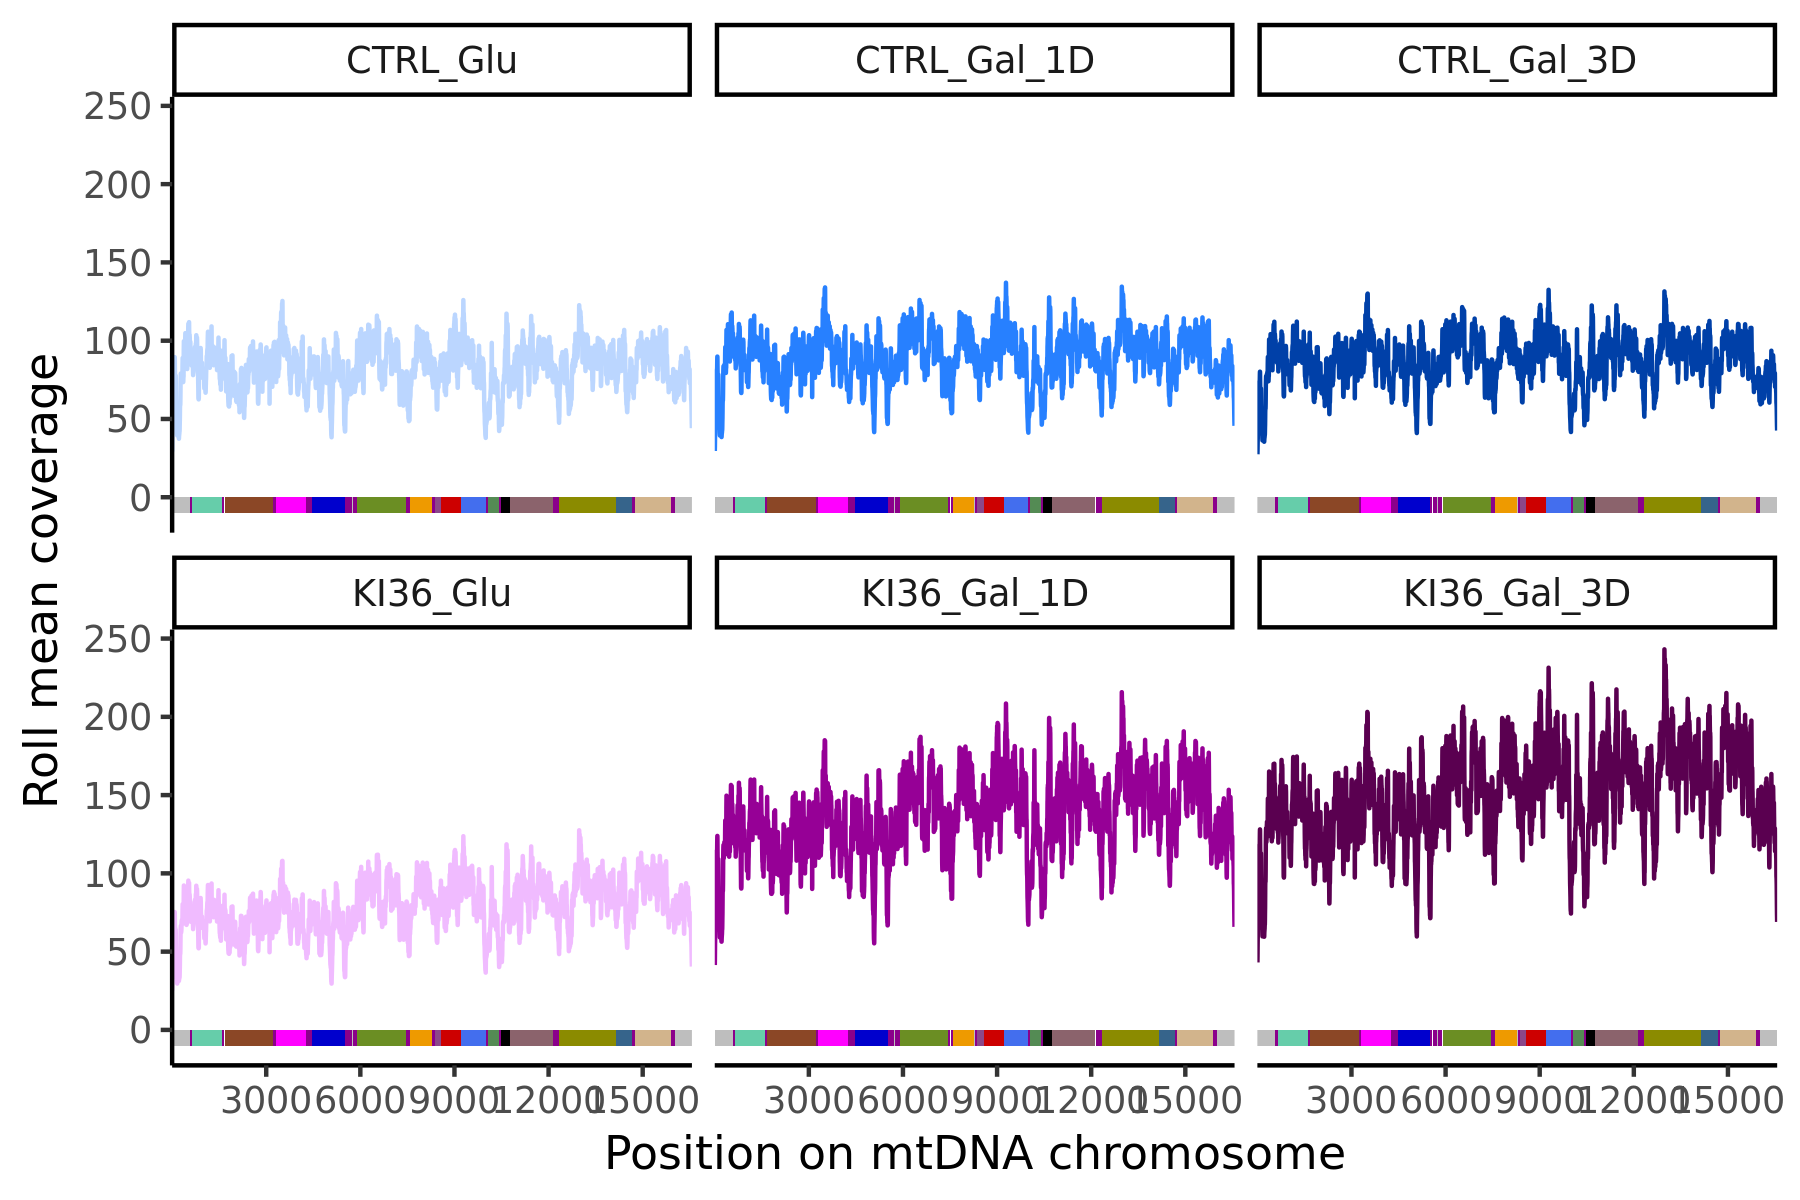

In [49]:
options(repr.plot.width = 6, repr.plot.height = 4, repr.plot.res = 300)
p9

In [50]:
ggsave(plot = p9, "../plot/1_9_roll_mean_cov.pdf", width = 7, height = 4)

### Variant calling

In [51]:
CTRL_GluD3_CB <- WhichCells(Gal, idents = "CTRL_Glu"    )
CTRL_GalD1_CB <- WhichCells(Gal, idents = "CTRL_Gal_1D" )
CTRL_GalD3_CB <- WhichCells(Gal, idents = "CTRL_Gal_3D" )
KI36_GluD3_CB <- WhichCells(Gal, idents = "KI36_Glu"    )
KI36_GalD1_CB <- WhichCells(Gal, idents = "KI36_Gal_1D" )
KI36_GalD3_CB <- WhichCells(Gal, idents = "KI36_Gal_3D" )